# Refactored train/test split pipeline
This notebook orchestrates the original `train_test_split.ipynb` workflow using code extracted into the `src` package.


In [6]:
import os
import sys
import numpy as np

# Allow imports from the project root
sys.path.insert(0, os.path.abspath('..'))

from src.data_prep import prepare_data
from src import regression
from src.pipeline import FEATURE_SETS, plot_feature_histograms, reset_output_dir, run_baseline_regressions
from src.model_comparison import run_model_comparison
from src.classification import run_classification_analysis

In [7]:
# Configuration flags and parameters
RUN_BASELINE_MODELS = True
BASELINE_PLOTTING = False
RANDOM_STATES = [1, 2, 3, 4, 5, 6, 7, 8, 9, 1000000]

RUN_HISTOGRAMS = True
RUN_CORNER = False
RUN_CORNER_BY_DATASET = False
RUN_RESIDUALS = False
RUN_CLASSIFICATION = True
RUN_MODEL_COMPARISON = True

MODEL_COMPARISON_SEEDS = [42, 123, 456, 789, 1010]
CLASSIFICATION_THRESHOLDS = np.arange(0.25, 0.66, 0.05)
CLASSIFICATION_FEATURES = ['tau', 'lin_age_err', 'met', 'met_err', 'logM', 'rad_kpc']

MIX_DATASETS = True

CORNER_FEATURES = ['met', 'tau', 'met_err', 'lin_age_err', 'logM', 'rad_kpc', 'MgFe', 'vdisp', 'DoR']
CORNER_TARGET_DISPLAY_NAME = r'$\mathrm{DoR}$'

RESIDUAL_FEATURES = ['tau', 'met']
RESIDUAL_MODEL_PARAMS = {
    'max_depth': 8,
    'max_features': 0.8,
    'max_samples': 0.7,
    'min_samples_leaf': 3,
    'min_samples_split': 5,
    'n_estimators': 50,
    'random_state': 42,
}


In [8]:
columns = ['vdisp','tau','MgFe', 'met_err', 'lin_age_err','met','rad_kpc','logM','DoR']
train_df, test_df = prepare_data(columns, restricted=False, pc=False, mix_datasets=MIX_DATASETS)

# Keep references for ensemble plots
regression.train_df = train_df
regression.test_df = test_df

# Unmixed data for E-INSPIRE vs INSPIRE histograms only
hist_train_df, hist_test_df = prepare_data(columns, restricted=False, pc=False, mix_datasets=False)


['ID', 'RAJ2000', 'DECJ2000', 'zspec_XSH', 'ageUni_at_z', 'Reff_median_KIDS_arcsec', 'Reff_median_KIDS_kpc', 'logM', 'Mstar(10^11)', 'vdisp', 'err_Vdisp_XSH', 'MgFe', 'err_alphafe', 'age_unr', 'age_rmax', 'lin_age_err', 'metal_unr', 'metal_rmax', 'met_err', 'tuni', 'Mtbb3', 'stdev_Mt3', 't_75', 'stdev_t75', 't_final', 'stdev_tifn', 'err_tfin', 'DoR', 'lin_age', 'met', 'SNR', 'rad_kpc', 'tau']
['ID', 'age_noboot', 'metals_noboot', 'age_boot', 'metals_boot', 'age_minus', 'metals_minus', 'ages_plus', 'metal_plus', 'GALAXY ID', 'univ_age', 'MgFe', 'vdisp', 'dor_26', 'logM', 'rad_kpc', 'age_err_mass', 'SNR', '[M/H]_mean_mass', '[M/H]_mean_1', 'DoR', '[M/H]', 'logAge_err', 'logAge', 'lin_age', 'lin_age_err', 'met_err', 'met', 'tau']
        vdisp       tau  MgFe   met_err  lin_age_err       met   rad_kpc  \
0  235.738250  0.080965   0.3  0.017160     0.190062  0.287000  0.502996   
1  211.042349  0.162209   0.2  0.021531     0.448946  0.242117  0.446138   
2  280.829136  0.082736   0.3  0.01

In [9]:
# Prepare output directory used throughout the pipeline
reset_output_dir('outputs/tests')


Model Name                          | Test R²: Mean ± Std       | Test R²: Min-Max          | Train R²: Mean ± Std      | Train R²: Min-Max        
------------------------------------------------------------------------------------------------------------------------
Complete Set                        | 0.8320 ± 0.0058 | 0.8232 - 0.8409 | 0.8237 ± 0.0065 | 0.8086 - 0.8320
Stel. pop.                          | 0.8205 ± 0.0053 | 0.8135 - 0.8291 | 0.7727 ± 0.0112 | 0.7418 - 0.7838
Stel. pop. and $\alpha$-abundance   | 0.8301 ± 0.0048 | 0.8237 - 0.8412 | 0.8277 ± 0.0076 | 0.8098 - 0.8355
Stel. pop. and kinematics           | 0.8317 ± 0.0034 | 0.8262 - 0.8374 | 0.8229 ± 0.0069 | 0.8089 - 0.8335
Stel. pop. and structural           | 0.8353 ± 0.0043 | 0.8297 - 0.8438 | 0.8190 ± 0.0065 | 0.8043 - 0.8272
Stel. pop. with errors              | 0.8316 ± 0.0045 | 0.8231 - 0.8381 | 0.8239 ± 0.0083 | 0.8024 - 0.8330
Stel. pop., $\alpha$-abundance and kinematics | 0.8292 ± 0.0044 | 0.8237 - 0.8360 |

/Users/charl/Programming/AS01_E_INSPIRE/src/regression.py:855: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  ensemble_results = pd.concat([ensemble_results, pd.DataFrame({



R² Variation Metrics Across Random Seeds:
                                         name  test_r2_avg  test_r2_std  train_r2_avg  train_r2_std
                                 Complete Set        0.832        0.006         0.824         0.006
                                   Stel. pop.        0.821        0.005         0.770         0.010
            Stel. pop. and $\alpha$-abundance        0.830        0.005         0.828         0.007
                    Stel. pop. and kinematics        0.832        0.003         0.823         0.007
                    Stel. pop. and structural        0.835        0.004         0.819         0.006
                       Stel. pop. with errors        0.832        0.004         0.824         0.008
Stel. pop., $\alpha$-abundance and kinematics        0.829        0.004         0.822         0.007
        Stel. pop., structural and kinematics        0.833        0.004         0.821         0.006


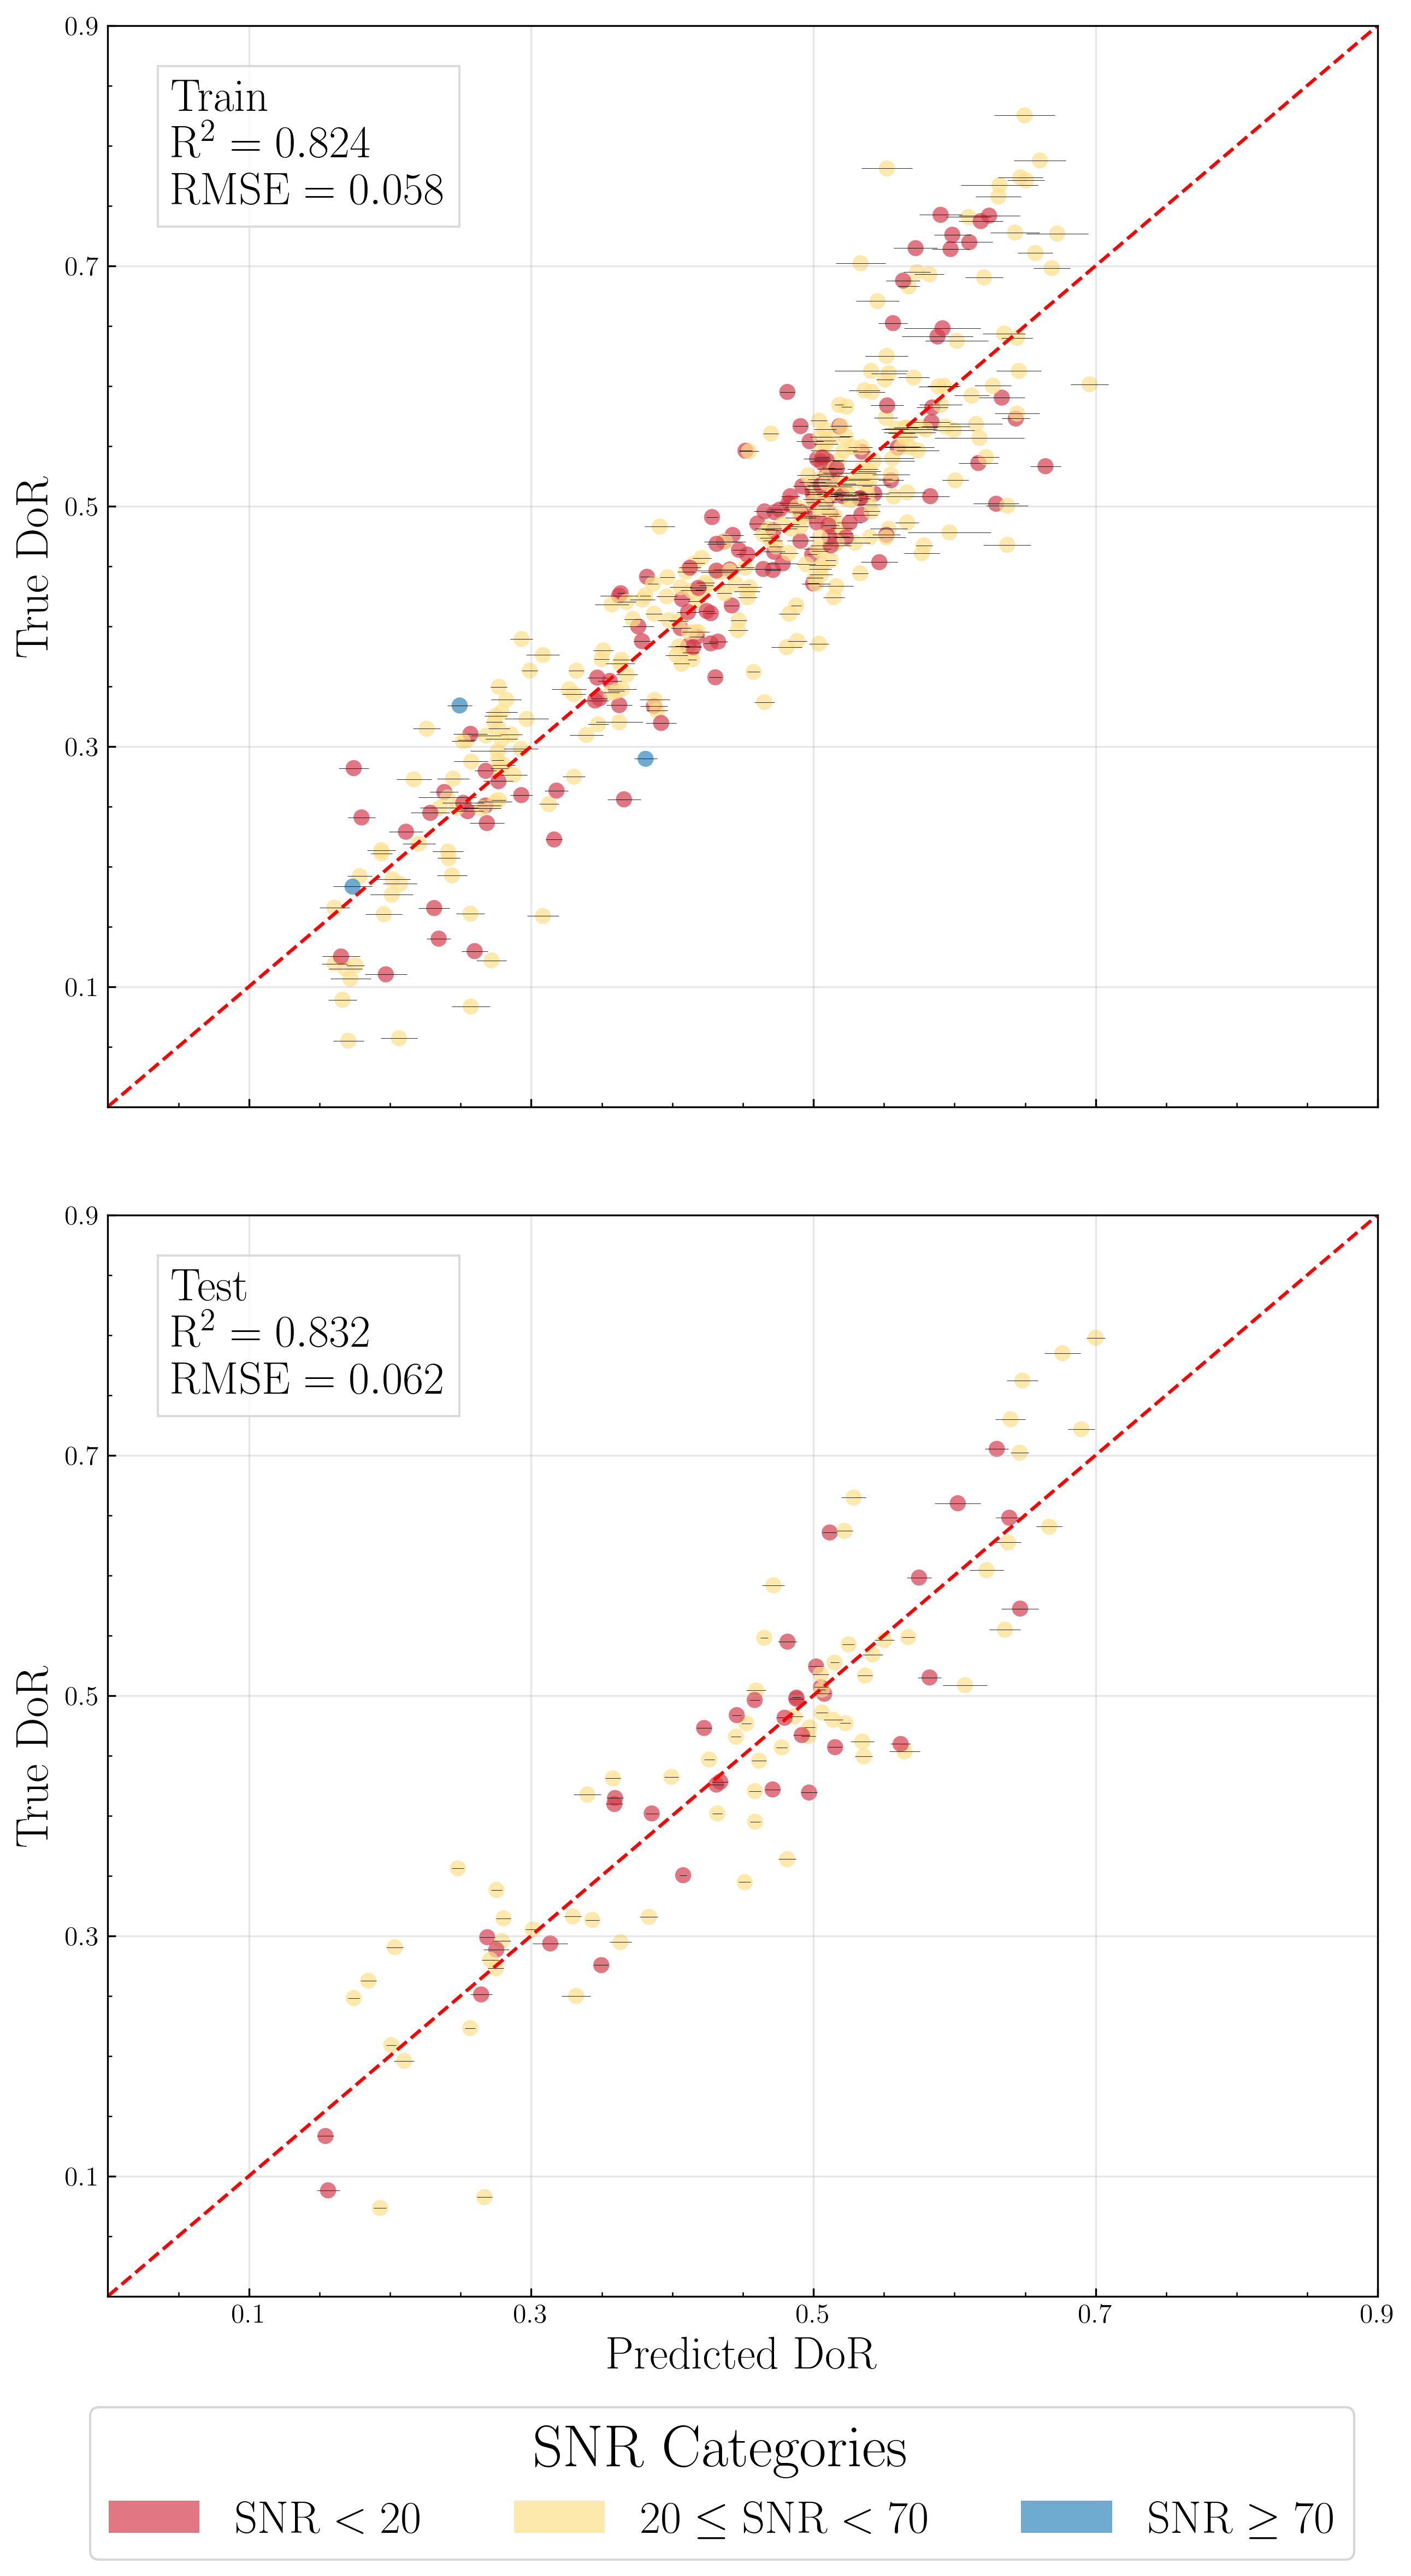

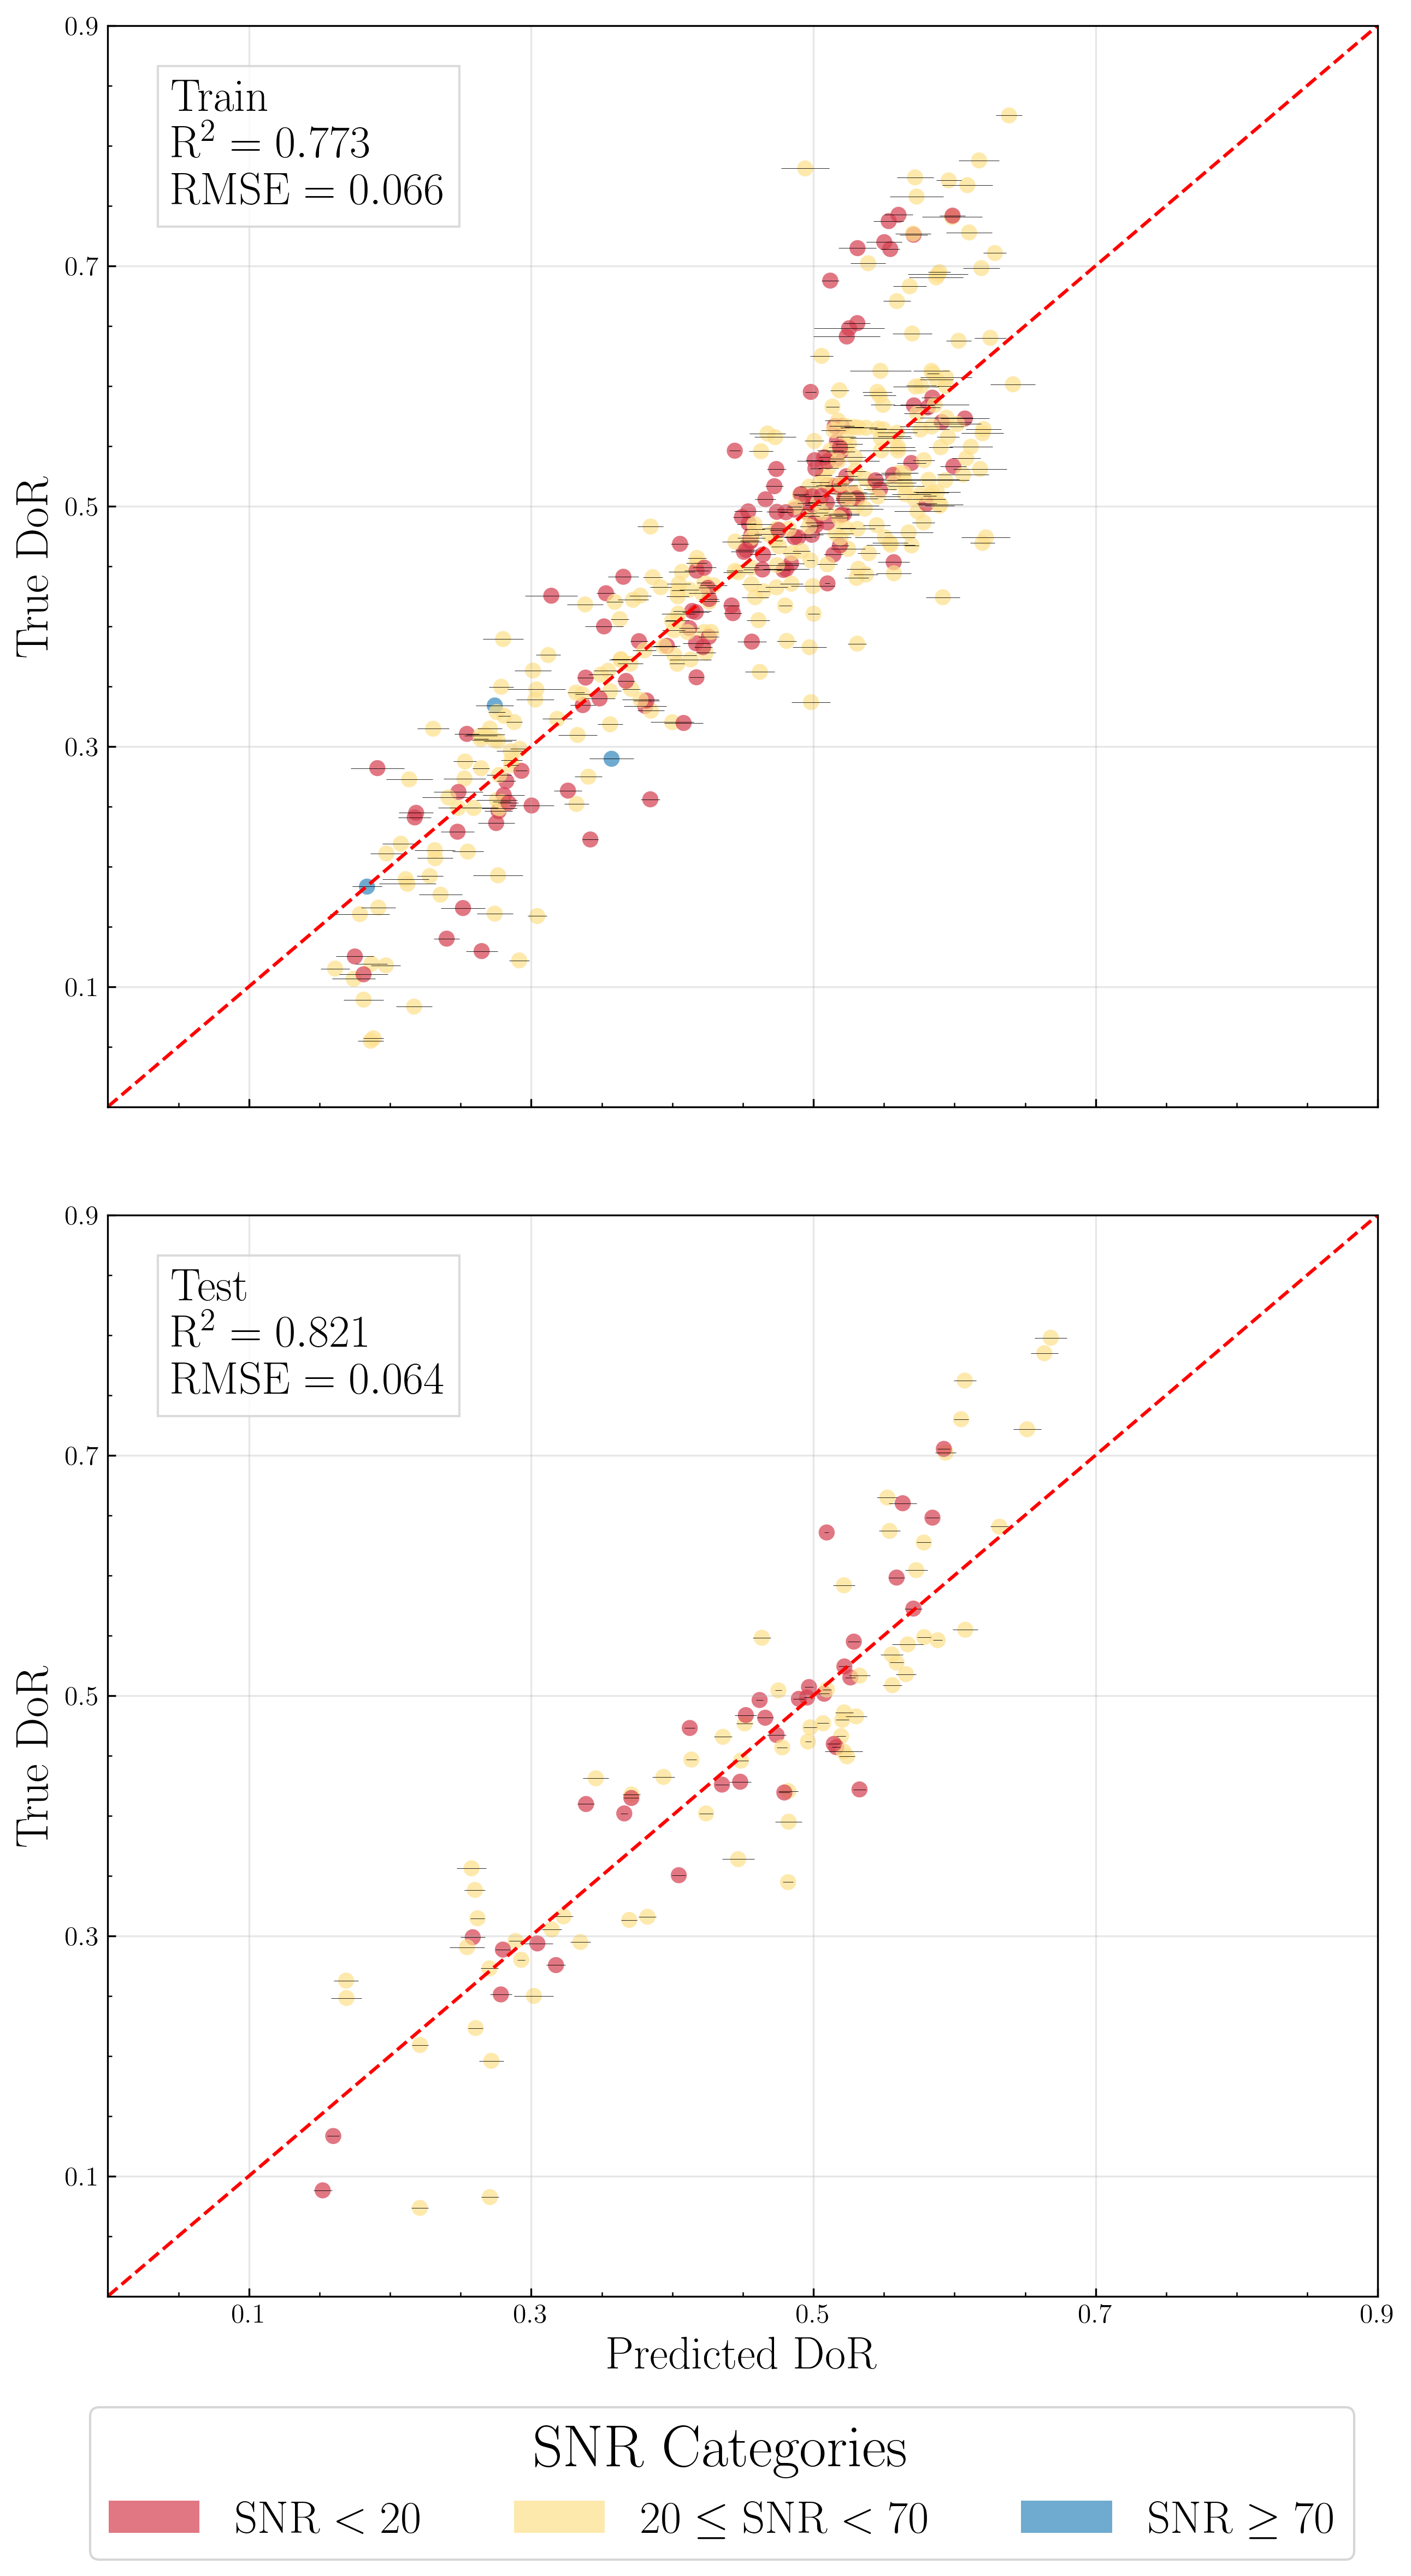

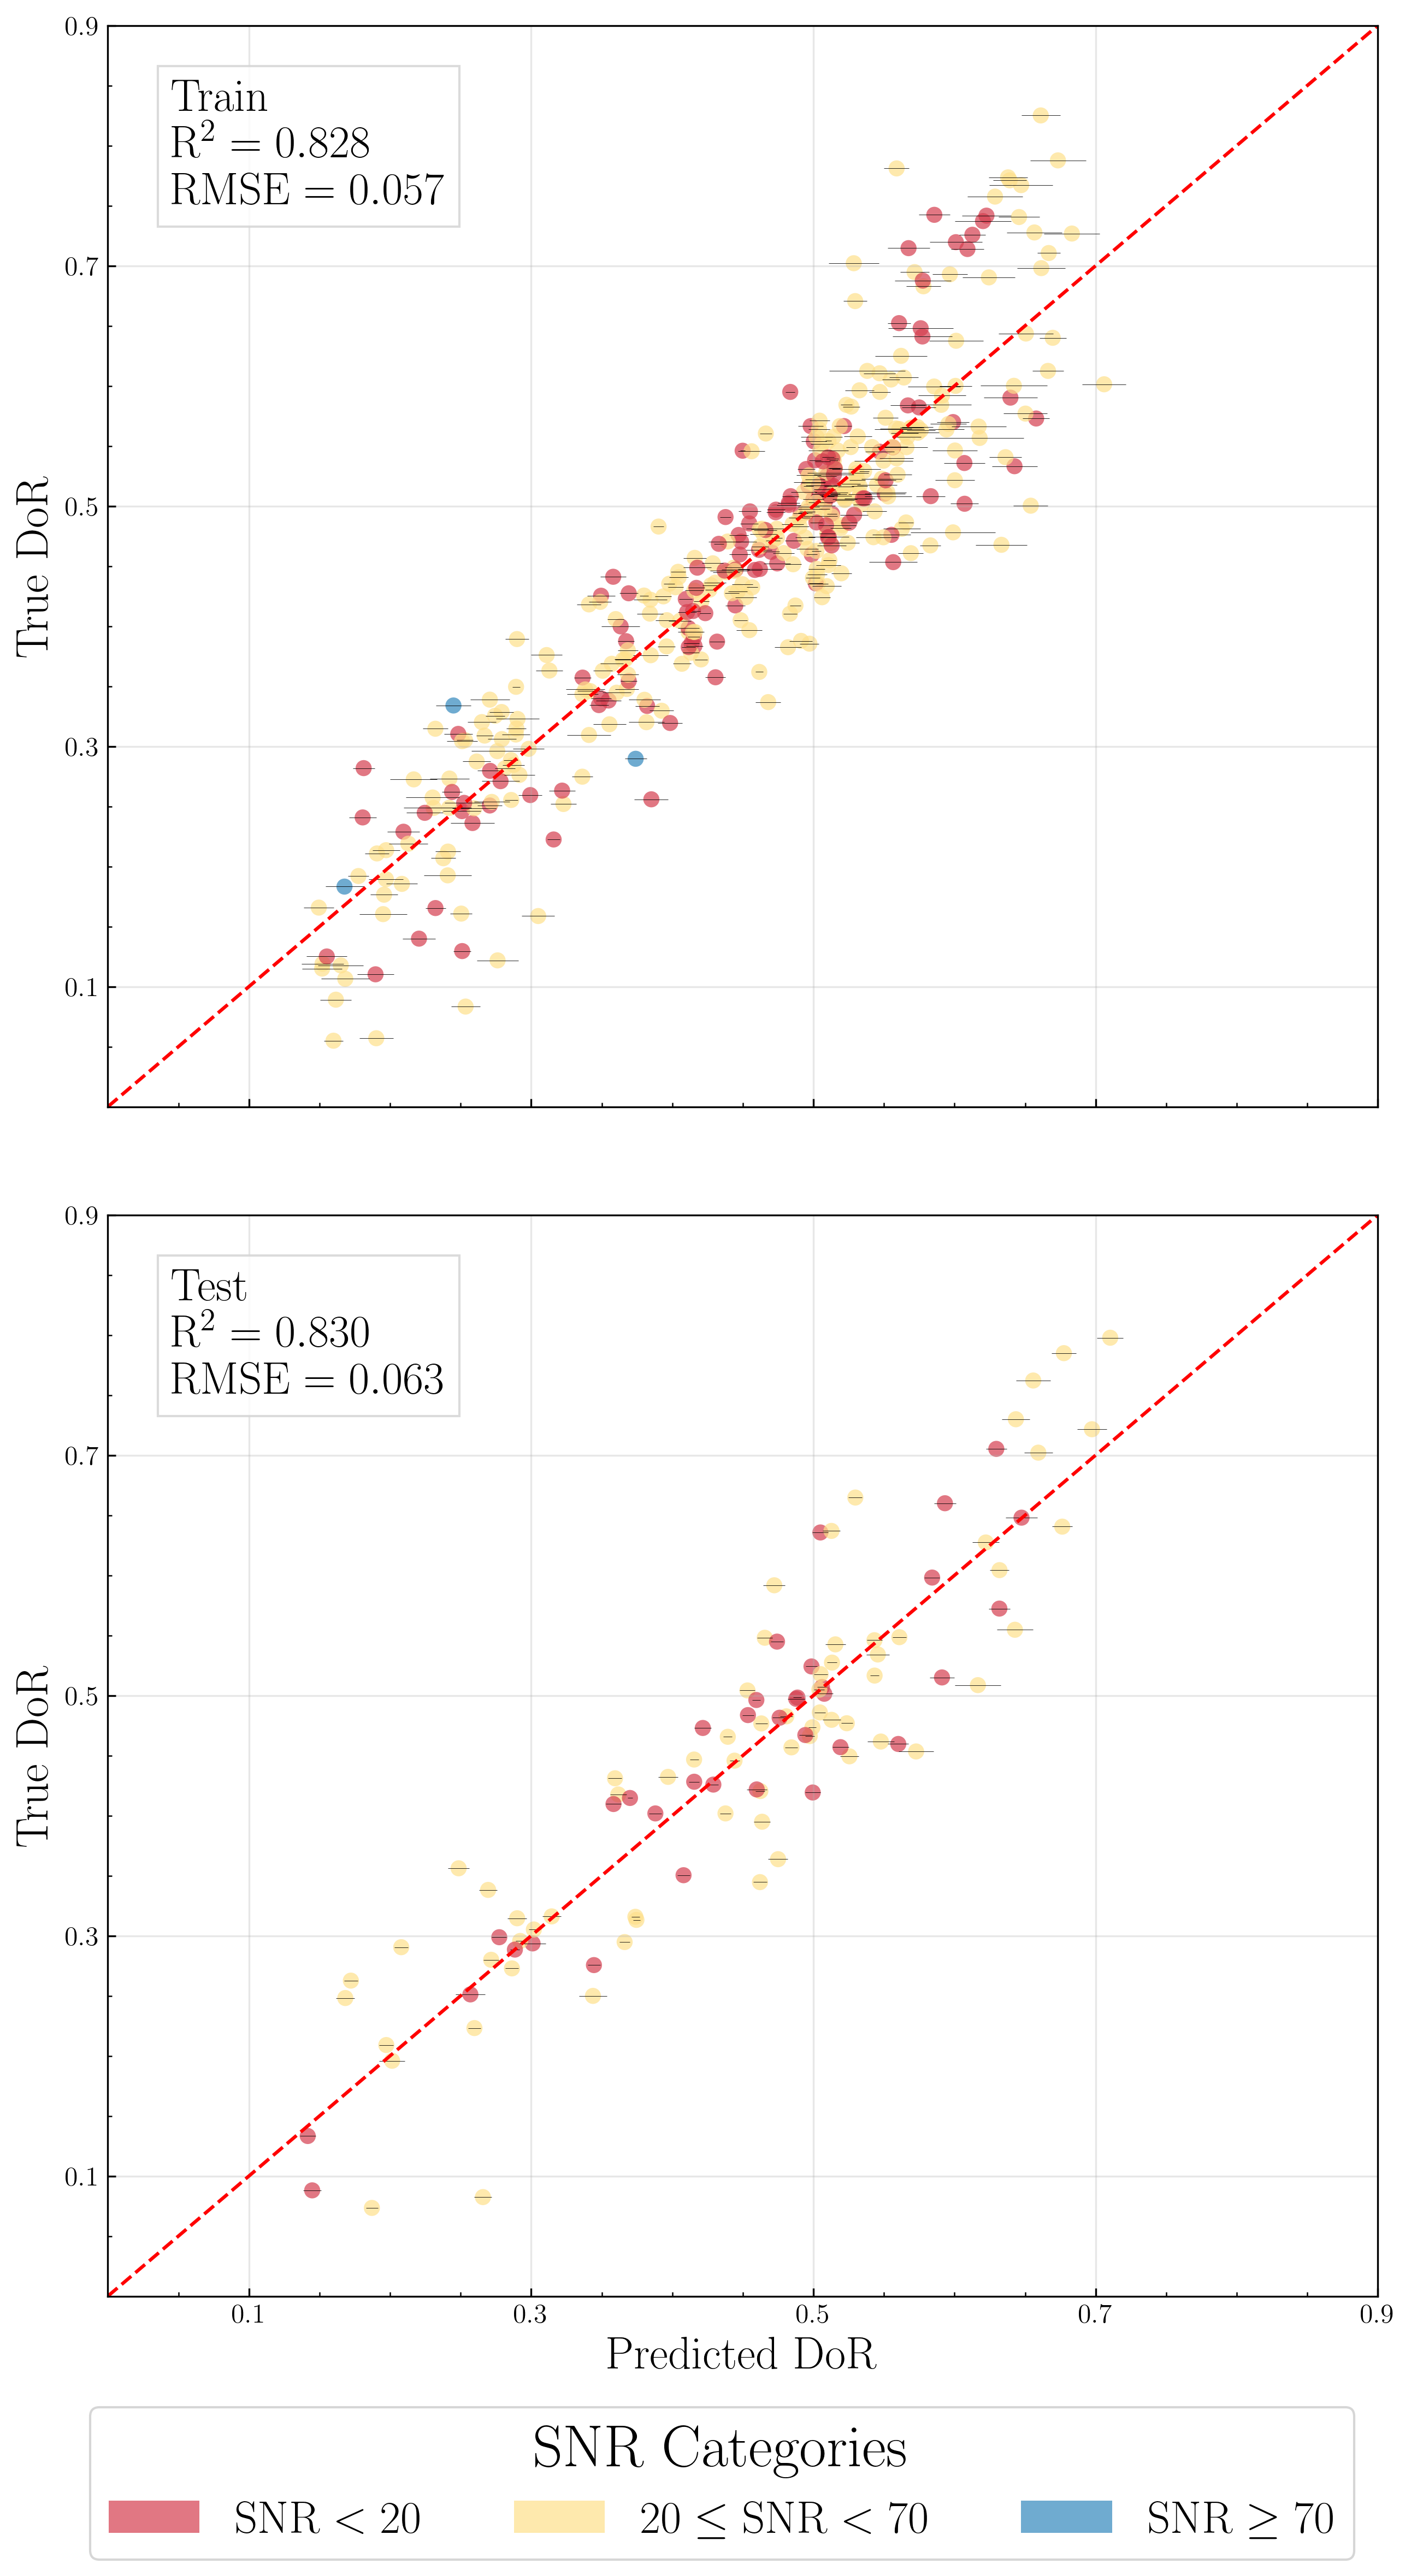

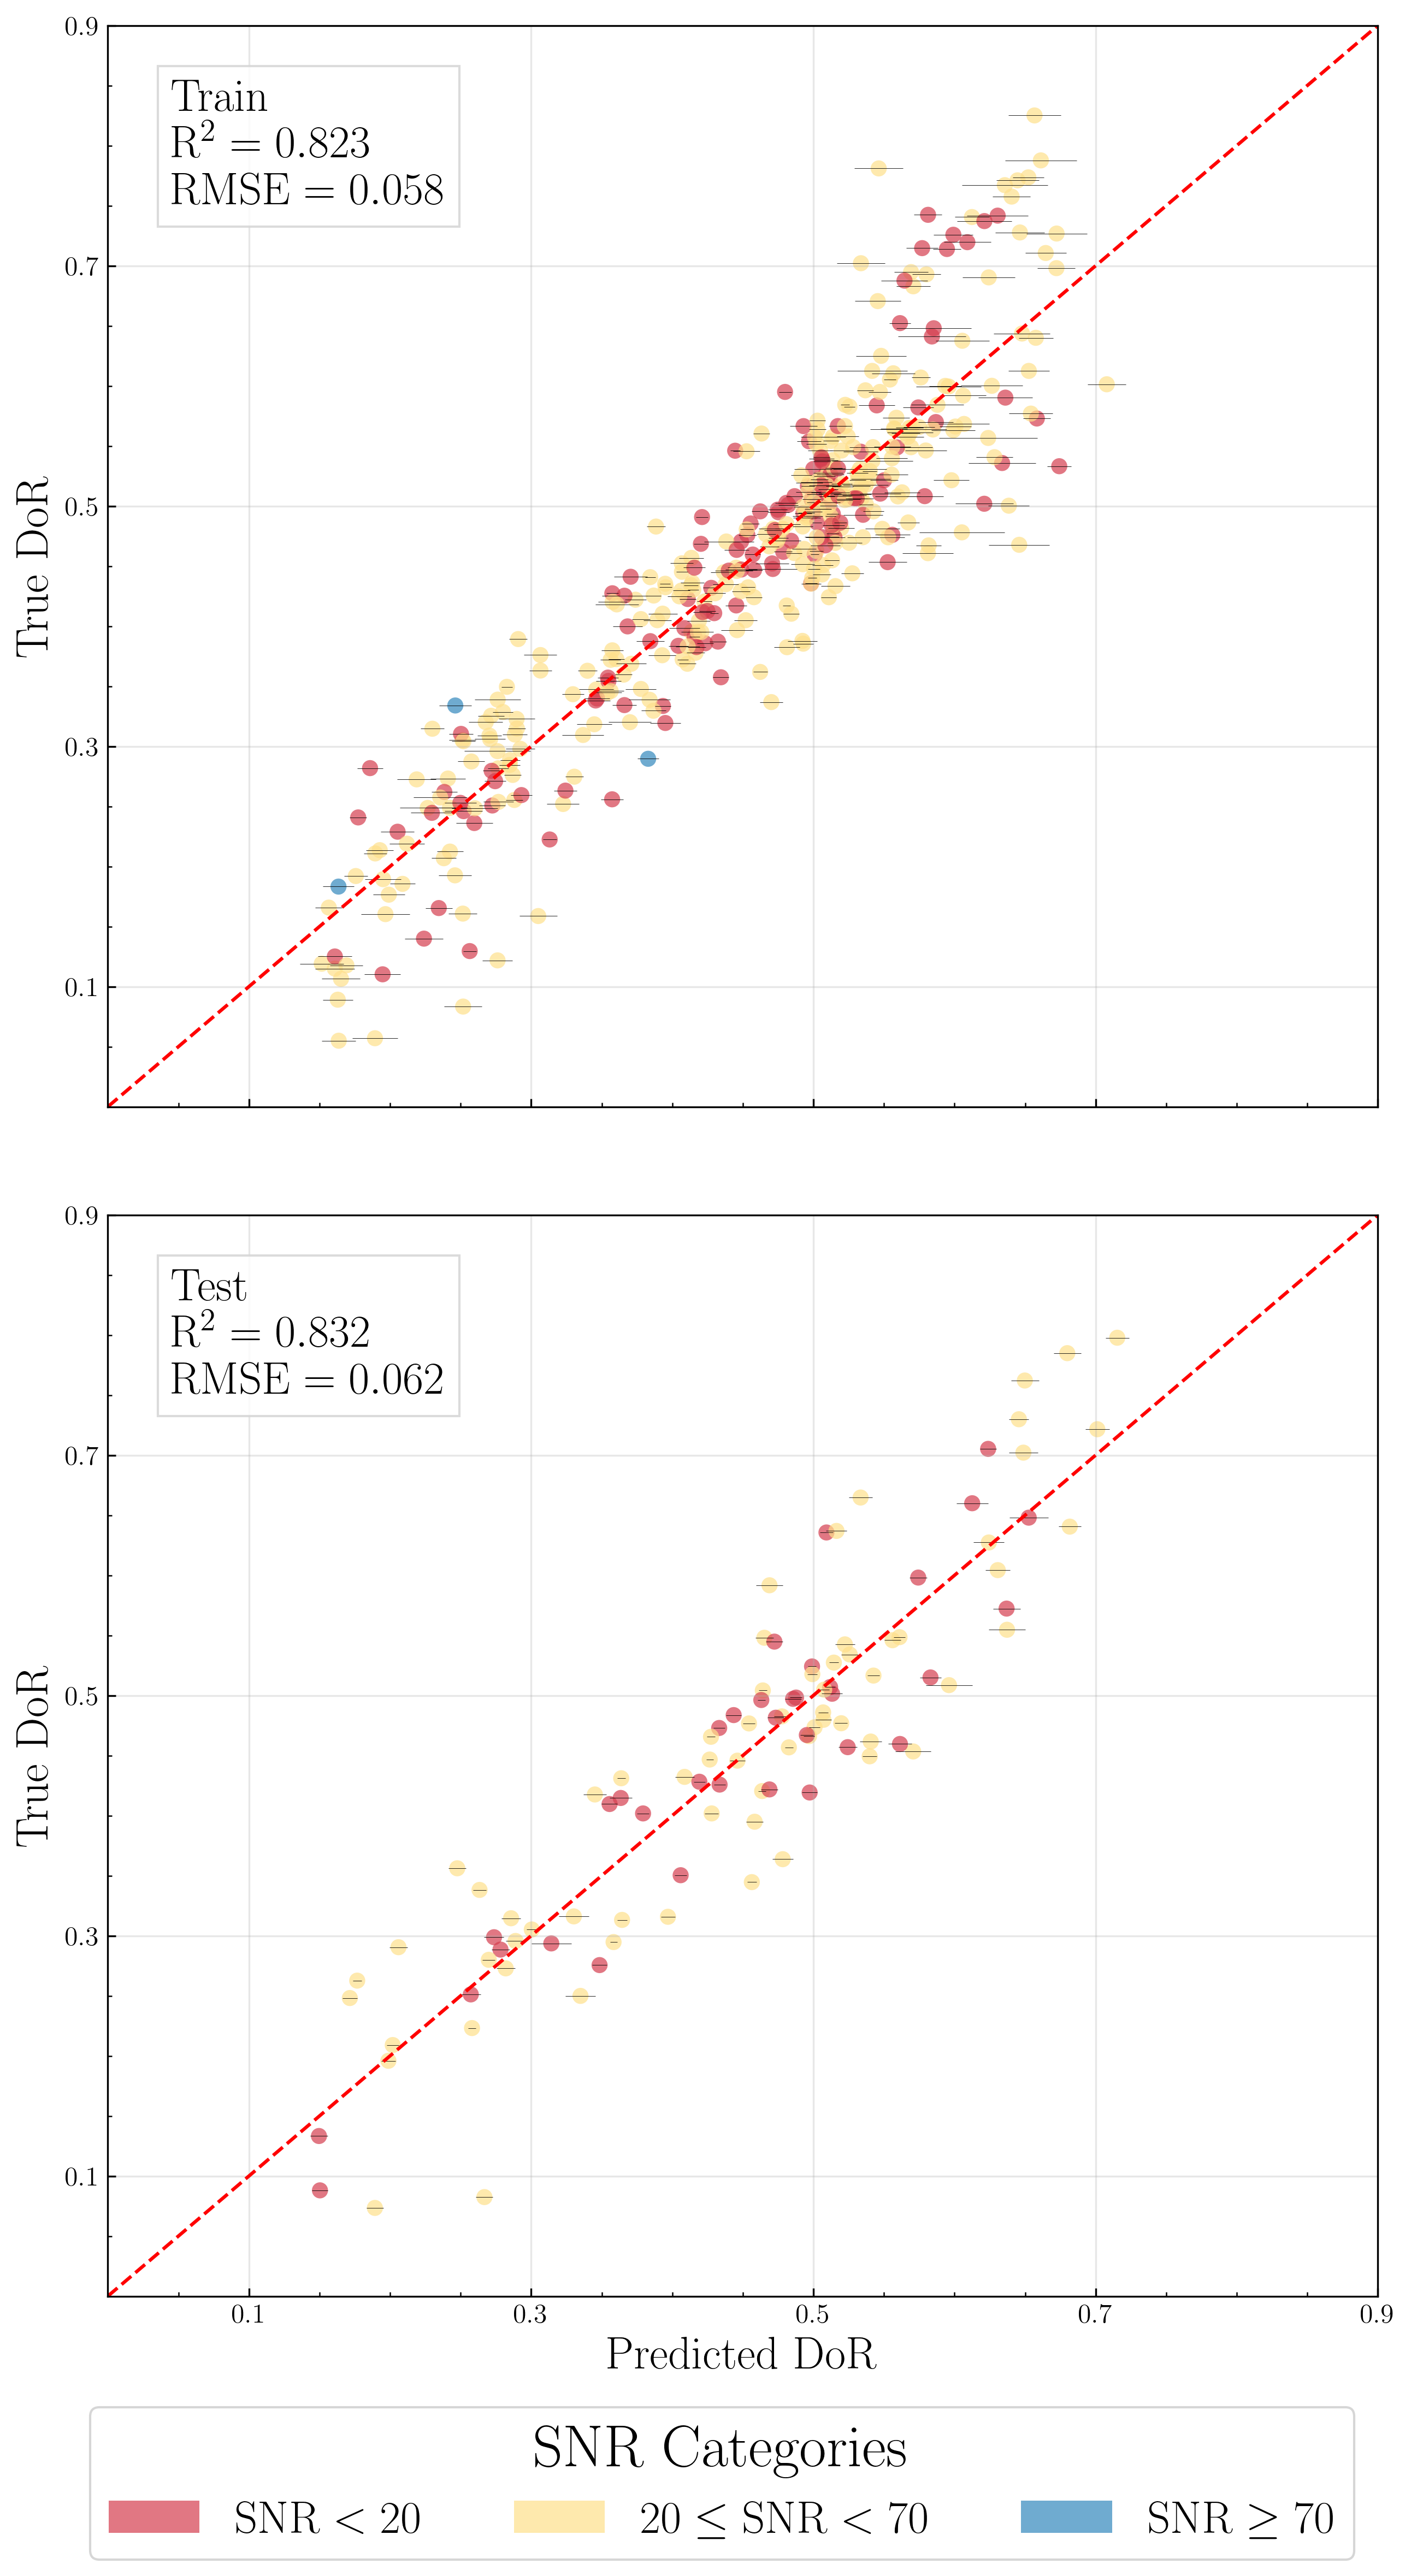

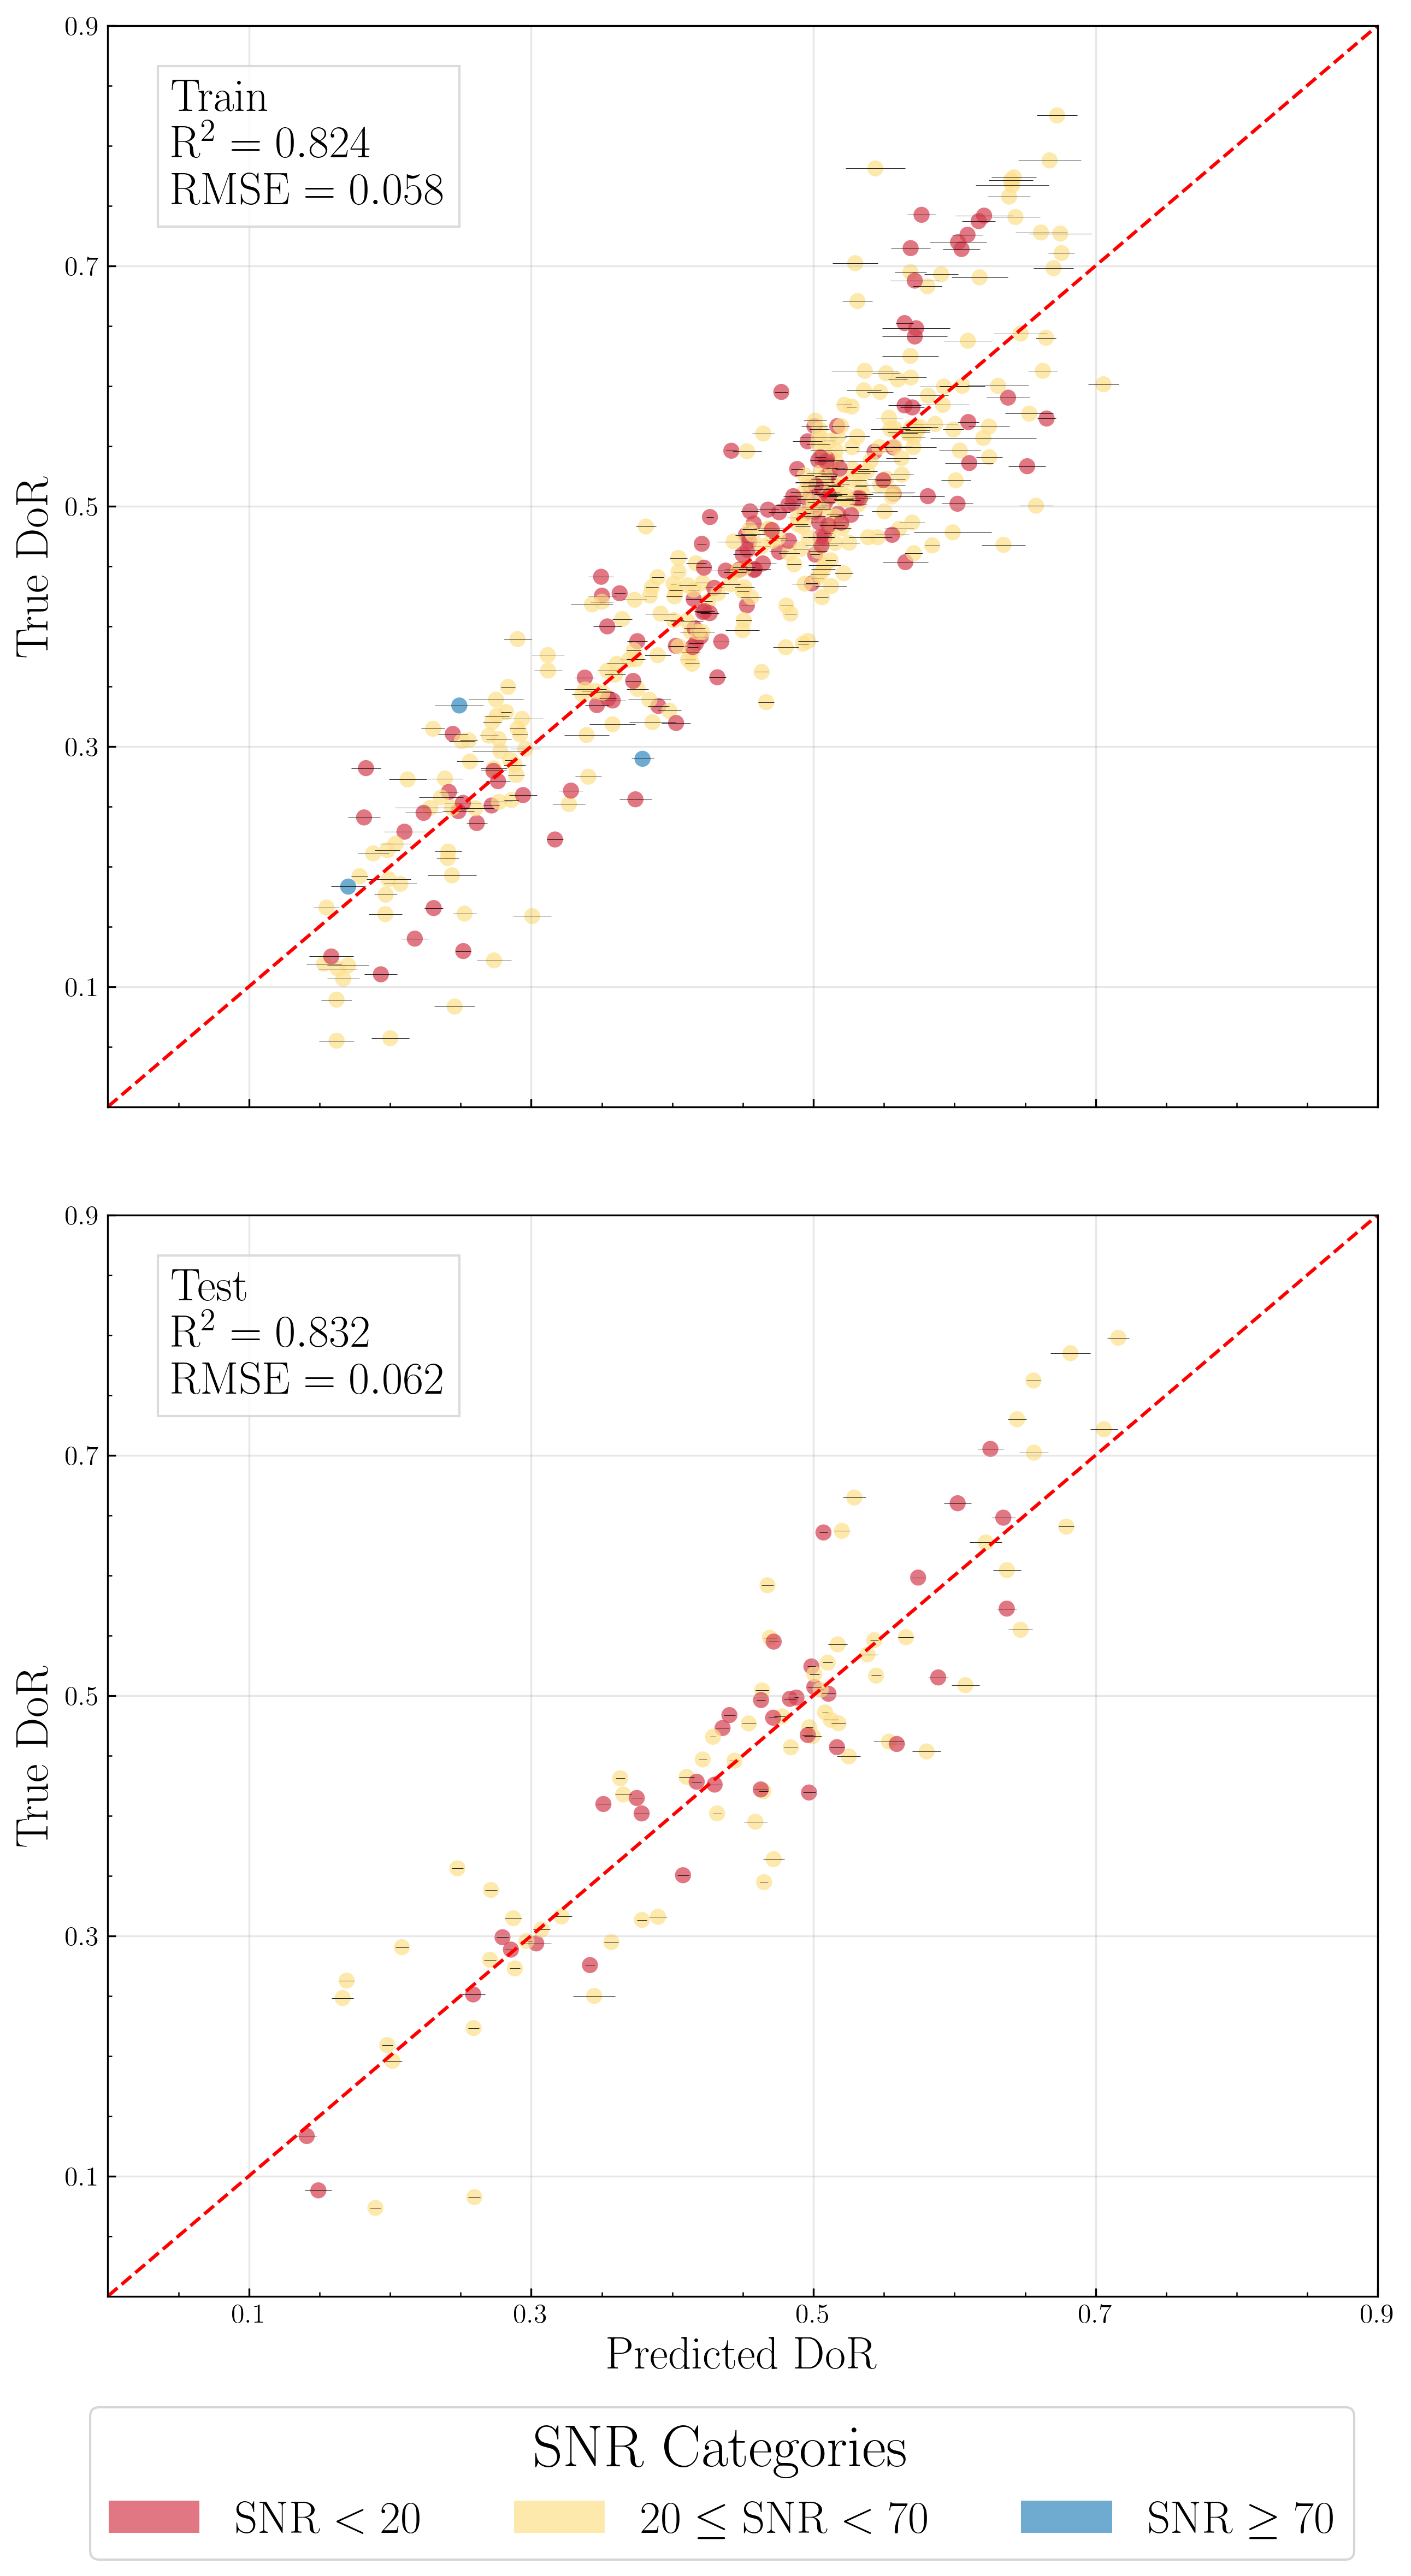

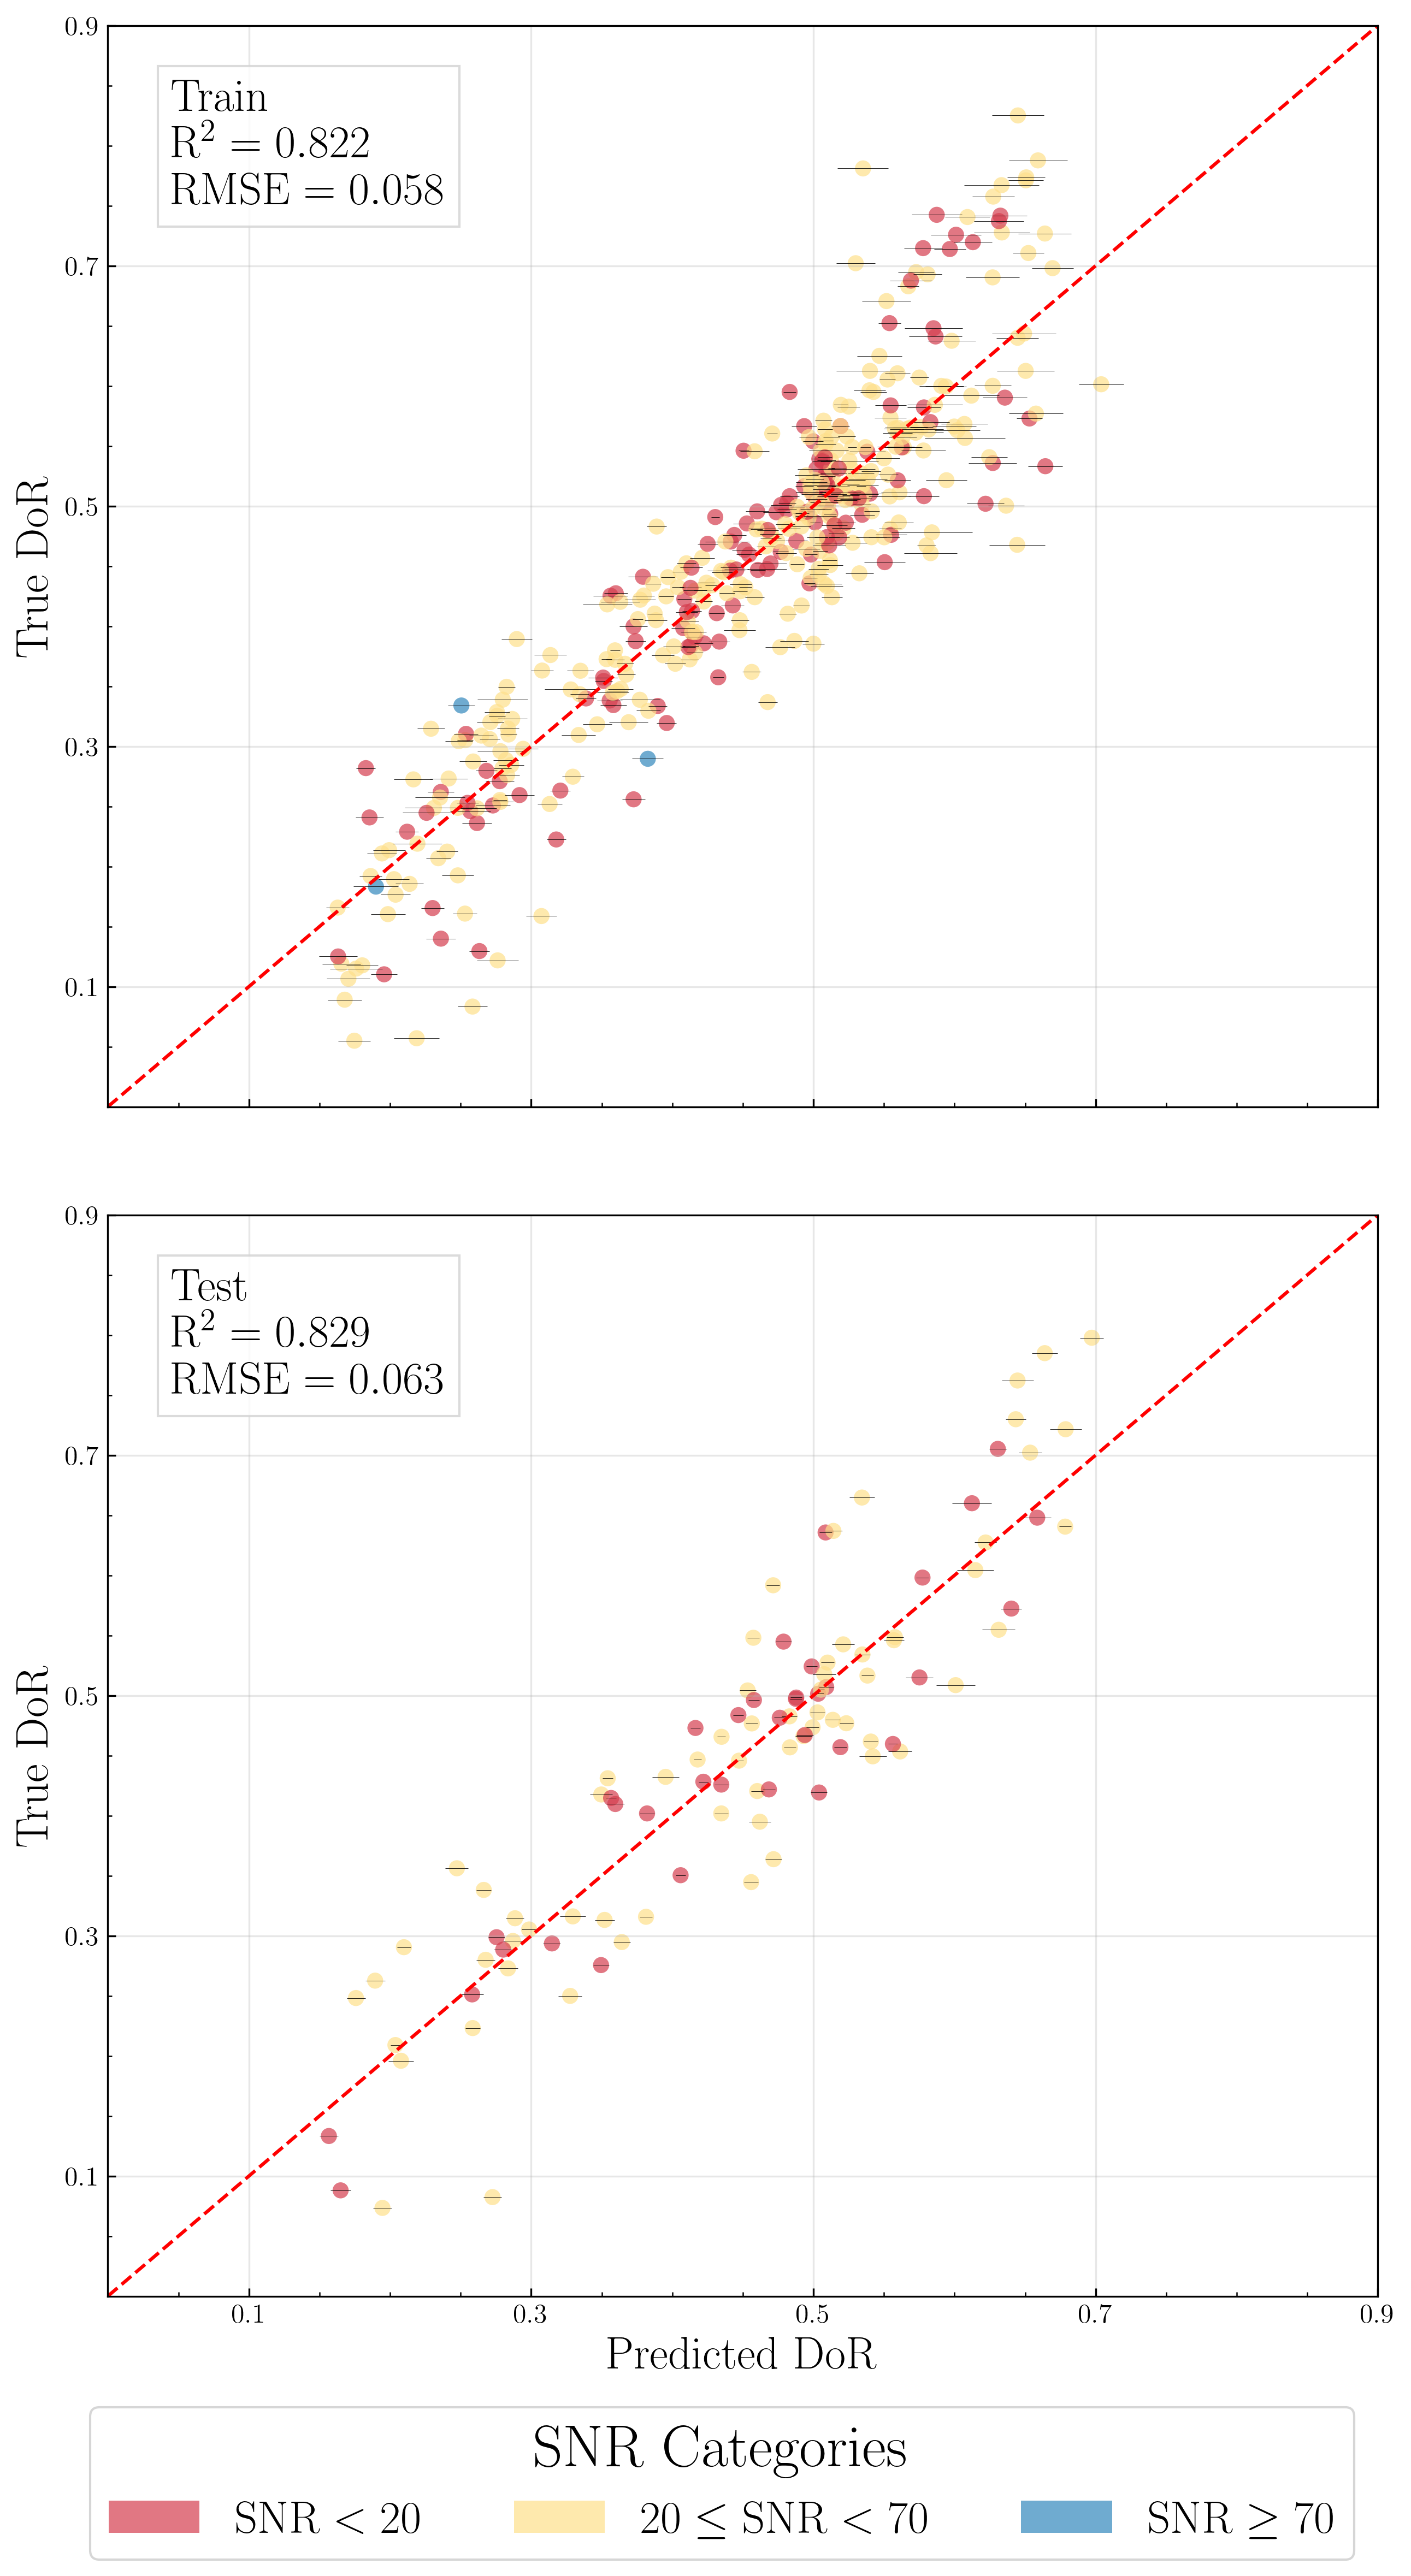

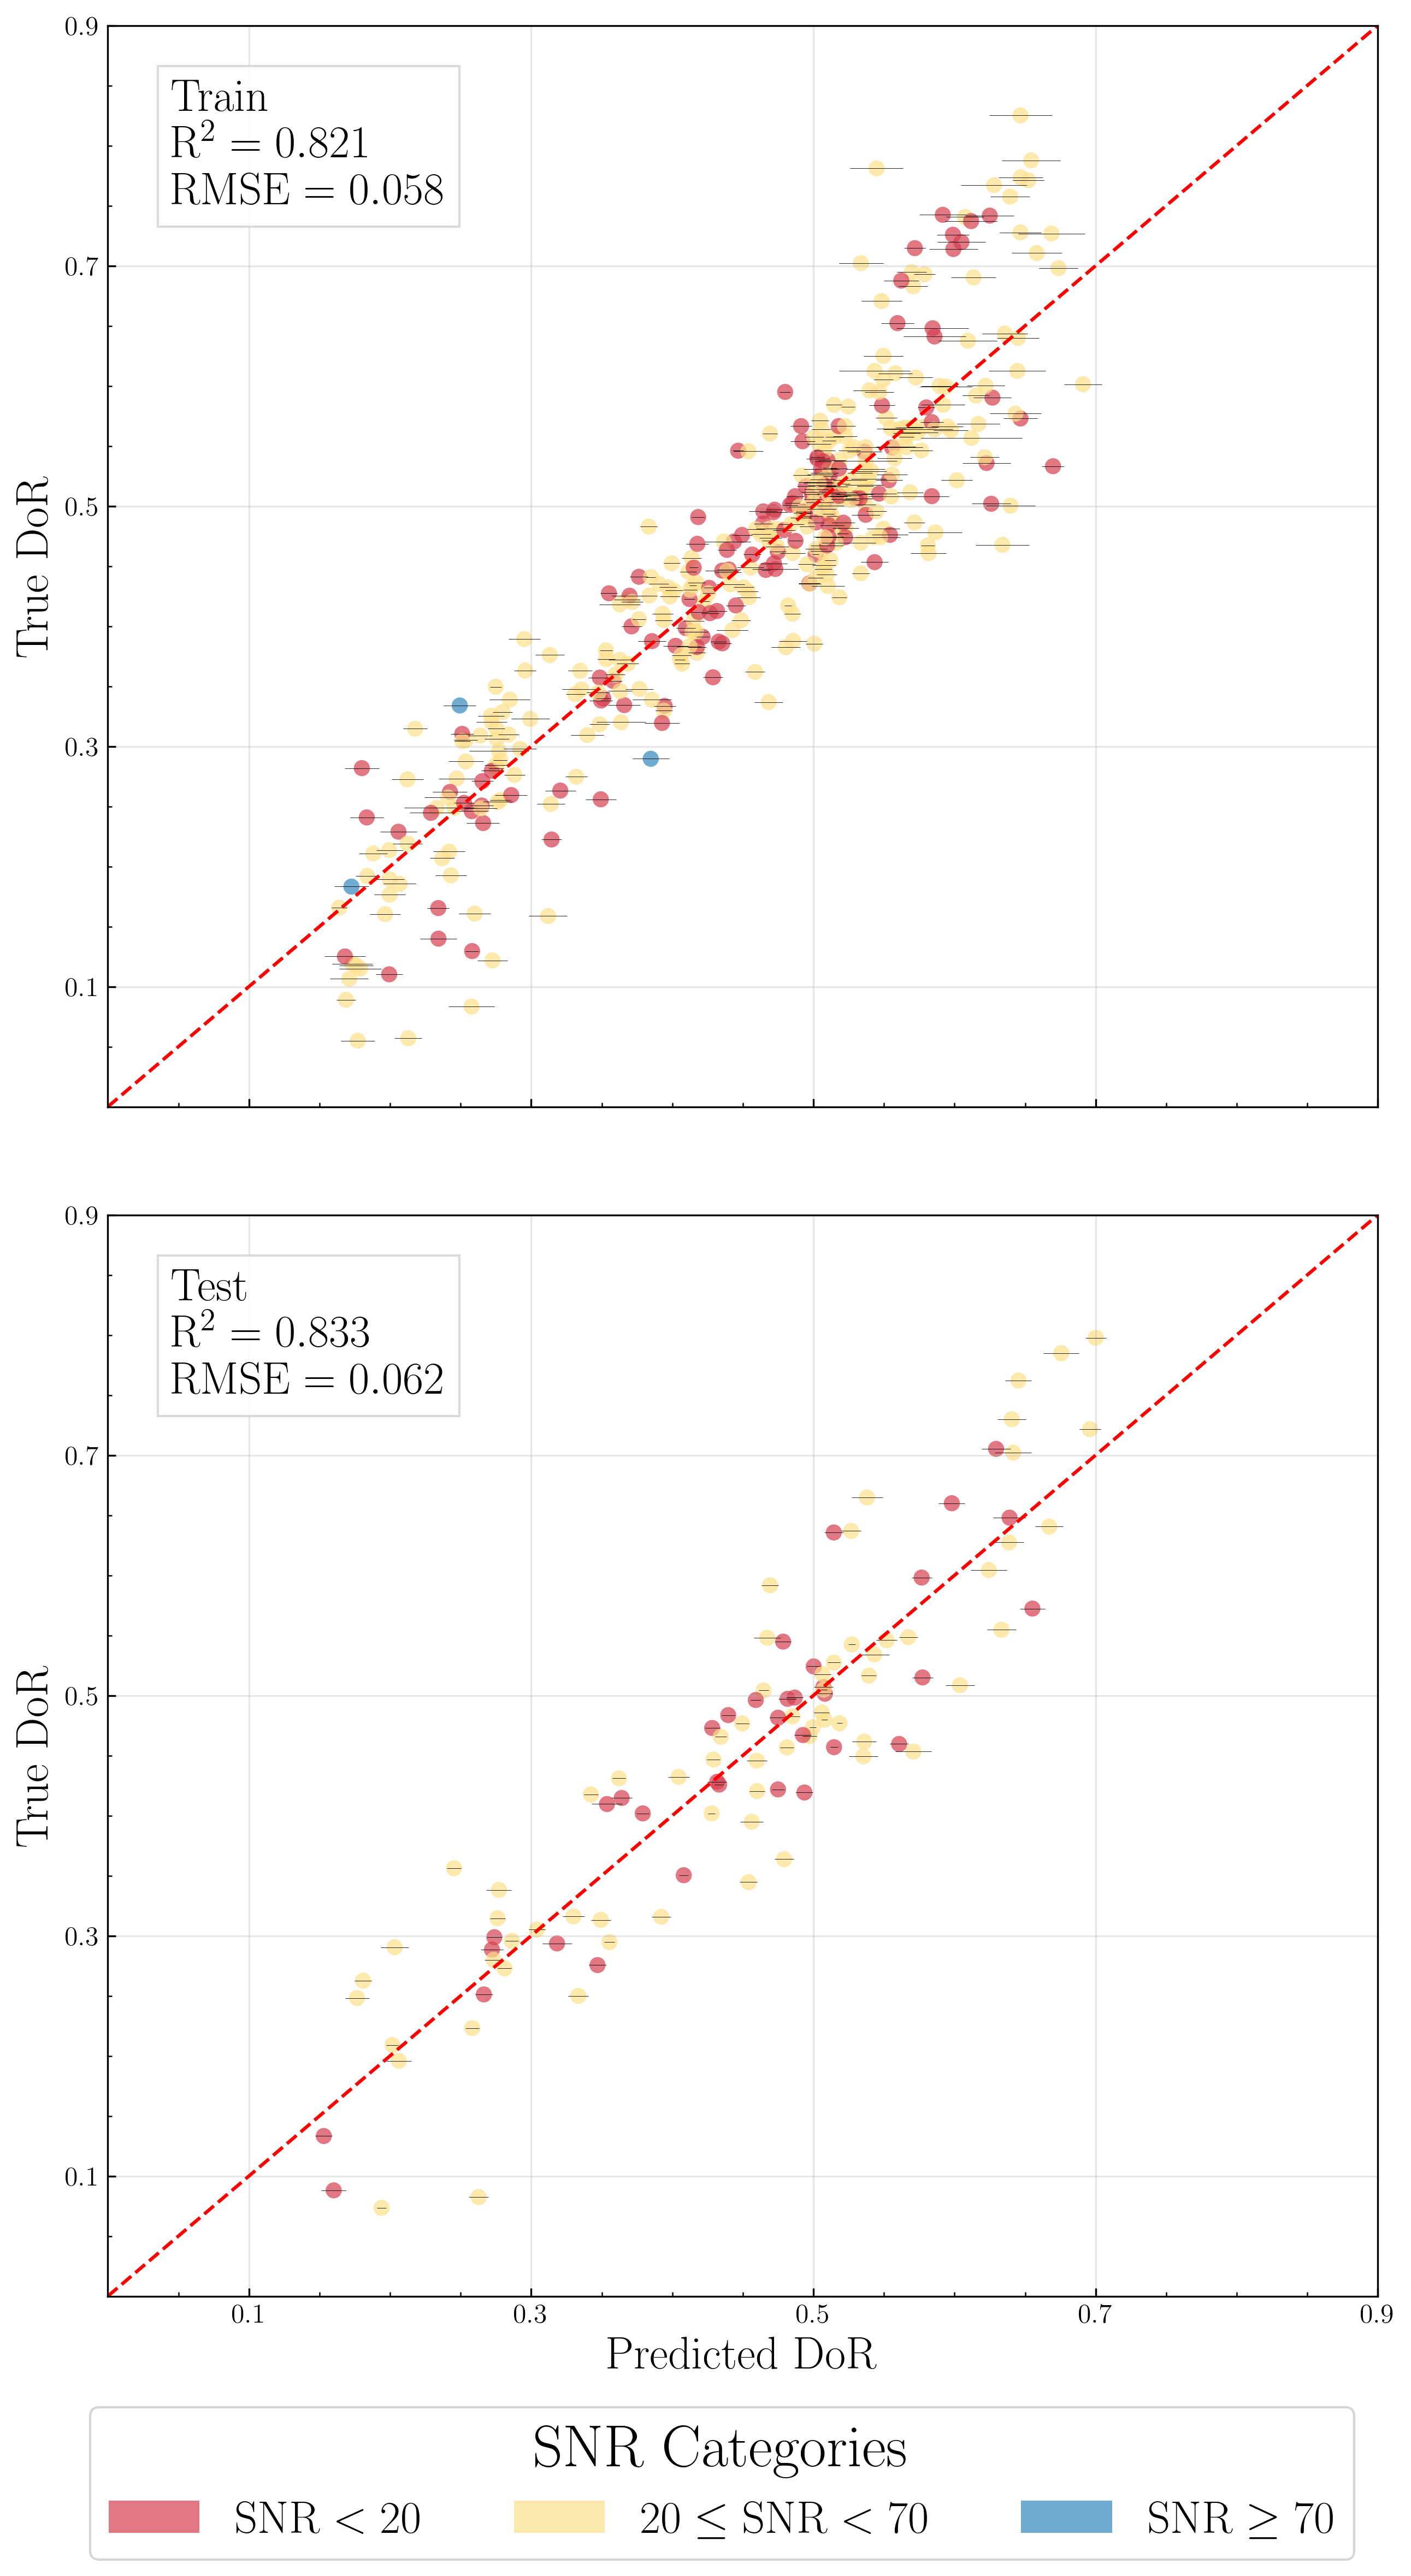

In [10]:
if RUN_BASELINE_MODELS:
    run_baseline_regressions(train_df, test_df, RANDOM_STATES, plotting=BASELINE_PLOTTING)
    regression.print_results_summary()
    ensemble_results = regression.calculate_ensemble_metrics()


In [11]:
if RUN_HISTOGRAMS:
    plot_feature_histograms(hist_train_df, hist_test_df)


In [12]:
if RUN_CORNER:
    regression.create_corner_plots(
        hist_test_df,
        CORNER_FEATURES,
        target='DoR',
        target_display_name=CORNER_TARGET_DISPLAY_NAME,
    )
    regression.create_corner_plots(
        hist_train_df,
        CORNER_FEATURES,
        target='DoR',
        target_display_name=CORNER_TARGET_DISPLAY_NAME,
    )


In [13]:
if RUN_CORNER_BY_DATASET:
    feature_display_names = {
        'met': r'$\mathrm{[M/H]}$',
        'tau': r'$\mathrm{\tau_{\rm rel}}$',
        'met_err': r'$\Delta{\mathrm{[M/H]}}$',
        'lin_age_err': r'$\Delta{\mathrm{Age}}$',
        'logM': r'$\log(M/M_{\odot})$',
        'rad_kpc': r'$R \, \mathrm{(kpc)}$',
        'MgFe': r'$\mathrm{[Mg/Fe]}$',
        'vdisp': r'$\sigma \star \mathrm{(km/s)}$',
        'DoR': r'$\mathrm{DoR}$',
    }
    regression.plot_features_by_dataset(
        hist_train_df,
        hist_test_df,
        CORNER_FEATURES,
        feature_display_names=feature_display_names,
    )


In [14]:
if RUN_RESIDUALS:
    regression.create_residual_analysis_report(
        train_df,
        test_df,
        RESIDUAL_FEATURES,
        'DoR',
        RESIDUAL_MODEL_PARAMS,
    )


In [15]:
if RUN_CLASSIFICATION:
    cv_results = run_classification_analysis(CLASSIFICATION_THRESHOLDS, CLASSIFICATION_FEATURES)


['ID', 'RAJ2000', 'DECJ2000', 'zspec_XSH', 'ageUni_at_z', 'Reff_median_KIDS_arcsec', 'Reff_median_KIDS_kpc', 'logM', 'Mstar(10^11)', 'vdisp', 'err_Vdisp_XSH', 'MgFe', 'err_alphafe', 'age_unr', 'age_rmax', 'lin_age_err', 'metal_unr', 'metal_rmax', 'met_err', 'tuni', 'Mtbb3', 'stdev_Mt3', 't_75', 'stdev_t75', 't_final', 'stdev_tifn', 'err_tfin', 'DoR', 'lin_age', 'met', 'SNR', 'rad_kpc', 'tau']
['ID', 'age_noboot', 'metals_noboot', 'age_boot', 'metals_boot', 'age_minus', 'metals_minus', 'ages_plus', 'metal_plus', 'GALAXY ID', 'univ_age', 'MgFe', 'vdisp', 'dor_26', 'logM', 'rad_kpc', 'age_err_mass', 'SNR', '[M/H]_mean_mass', '[M/H]_mean_1', 'DoR', '[M/H]', 'logAge_err', 'logAge', 'lin_age', 'lin_age_err', 'met_err', 'met', 'tau']
        vdisp       tau  MgFe   met_err  lin_age_err       met   rad_kpc  \
0  235.738250  0.080965   0.3  0.017160     0.190062  0.287000  0.502996   
1  211.042349  0.162209   0.2  0.021531     0.448946  0.242117  0.446138   
2  280.829136  0.082736   0.3  0.01


Running model comparison with 5 random seeds: [42, 123, 456, 789, 1010]...
['ID', 'RAJ2000', 'DECJ2000', 'zspec_XSH', 'ageUni_at_z', 'Reff_median_KIDS_arcsec', 'Reff_median_KIDS_kpc', 'logM', 'Mstar(10^11)', 'vdisp', 'err_Vdisp_XSH', 'MgFe', 'err_alphafe', 'age_unr', 'age_rmax', 'lin_age_err', 'metal_unr', 'metal_rmax', 'met_err', 'tuni', 'Mtbb3', 'stdev_Mt3', 't_75', 'stdev_t75', 't_final', 'stdev_tifn', 'err_tfin', 'DoR', 'lin_age', 'met', 'SNR', 'rad_kpc', 'tau']
['ID', 'age_noboot', 'metals_noboot', 'age_boot', 'metals_boot', 'age_minus', 'metals_minus', 'ages_plus', 'metal_plus', 'GALAXY ID', 'univ_age', 'MgFe', 'vdisp', 'dor_26', 'logM', 'rad_kpc', 'age_err_mass', 'SNR', '[M/H]_mean_mass', '[M/H]_mean_1', 'DoR', '[M/H]', 'logAge_err', 'logAge', 'lin_age', 'lin_age_err', 'met_err', 'met', 'tau']
        vdisp       tau  MgFe   met_err  lin_age_err       met   rad_kpc  \
0  235.738250  0.080965   0.3  0.017160     0.190062  0.287000  0.502996   
1  211.042349  0.162209   0.2  0.02

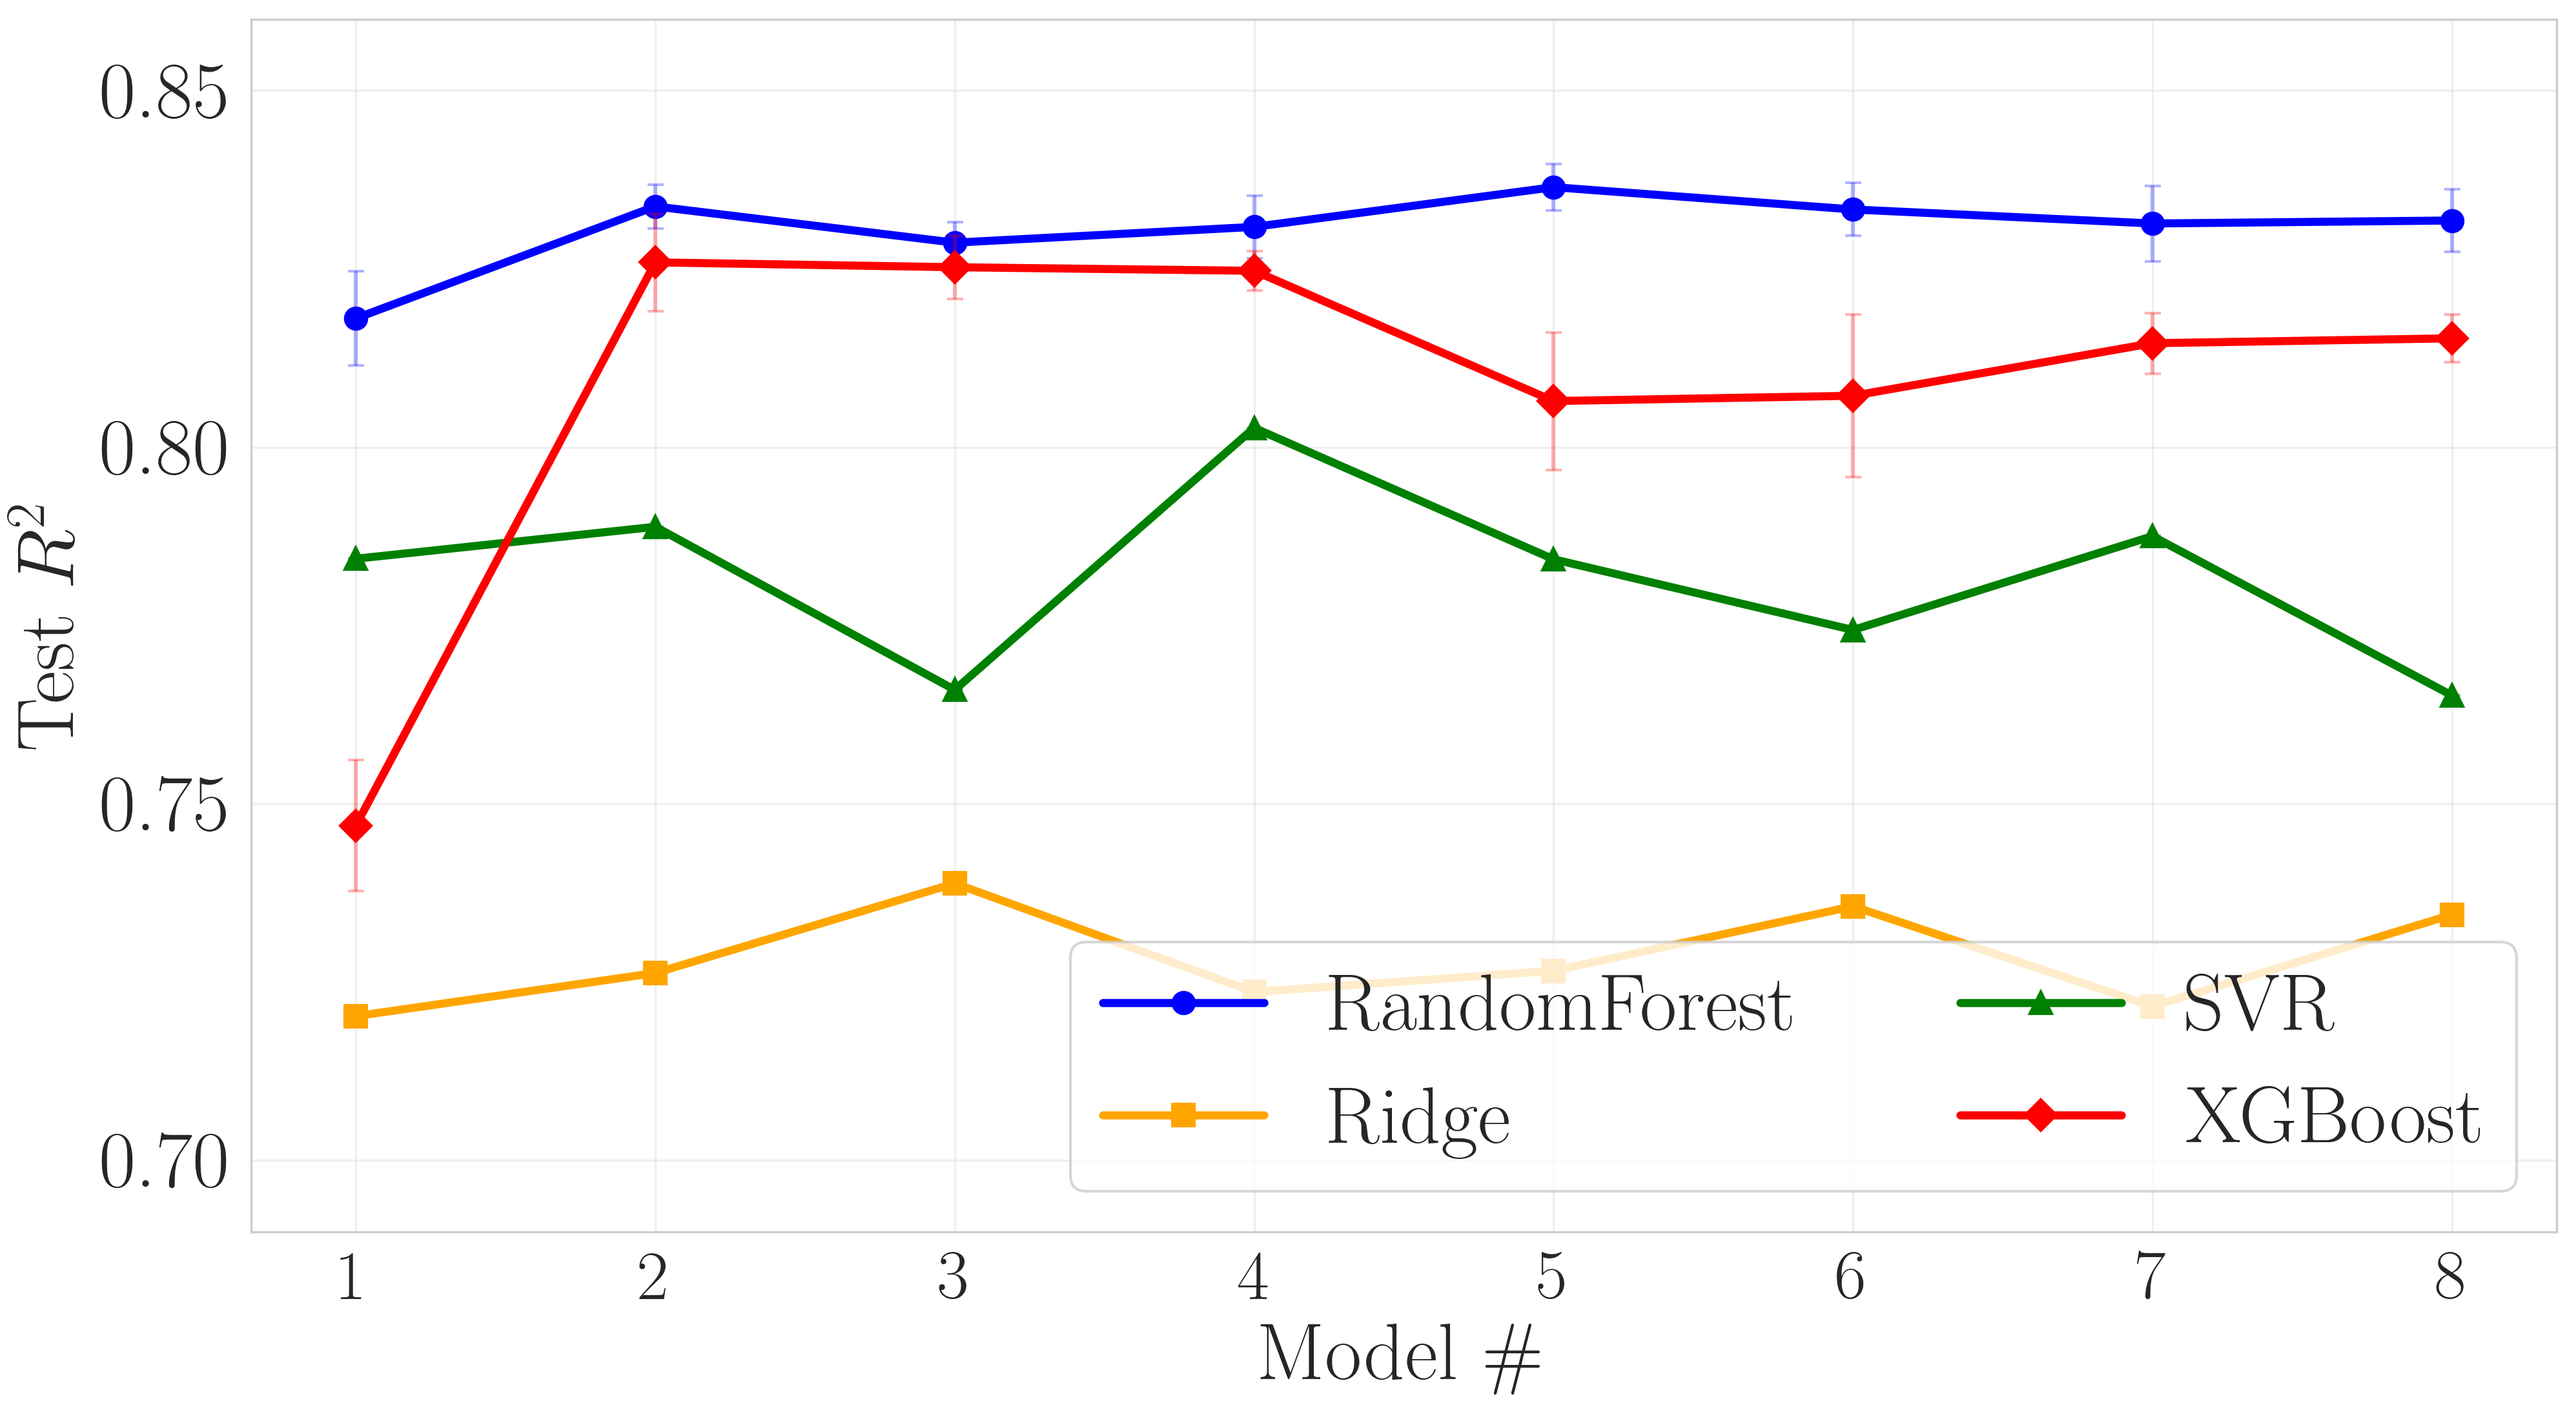

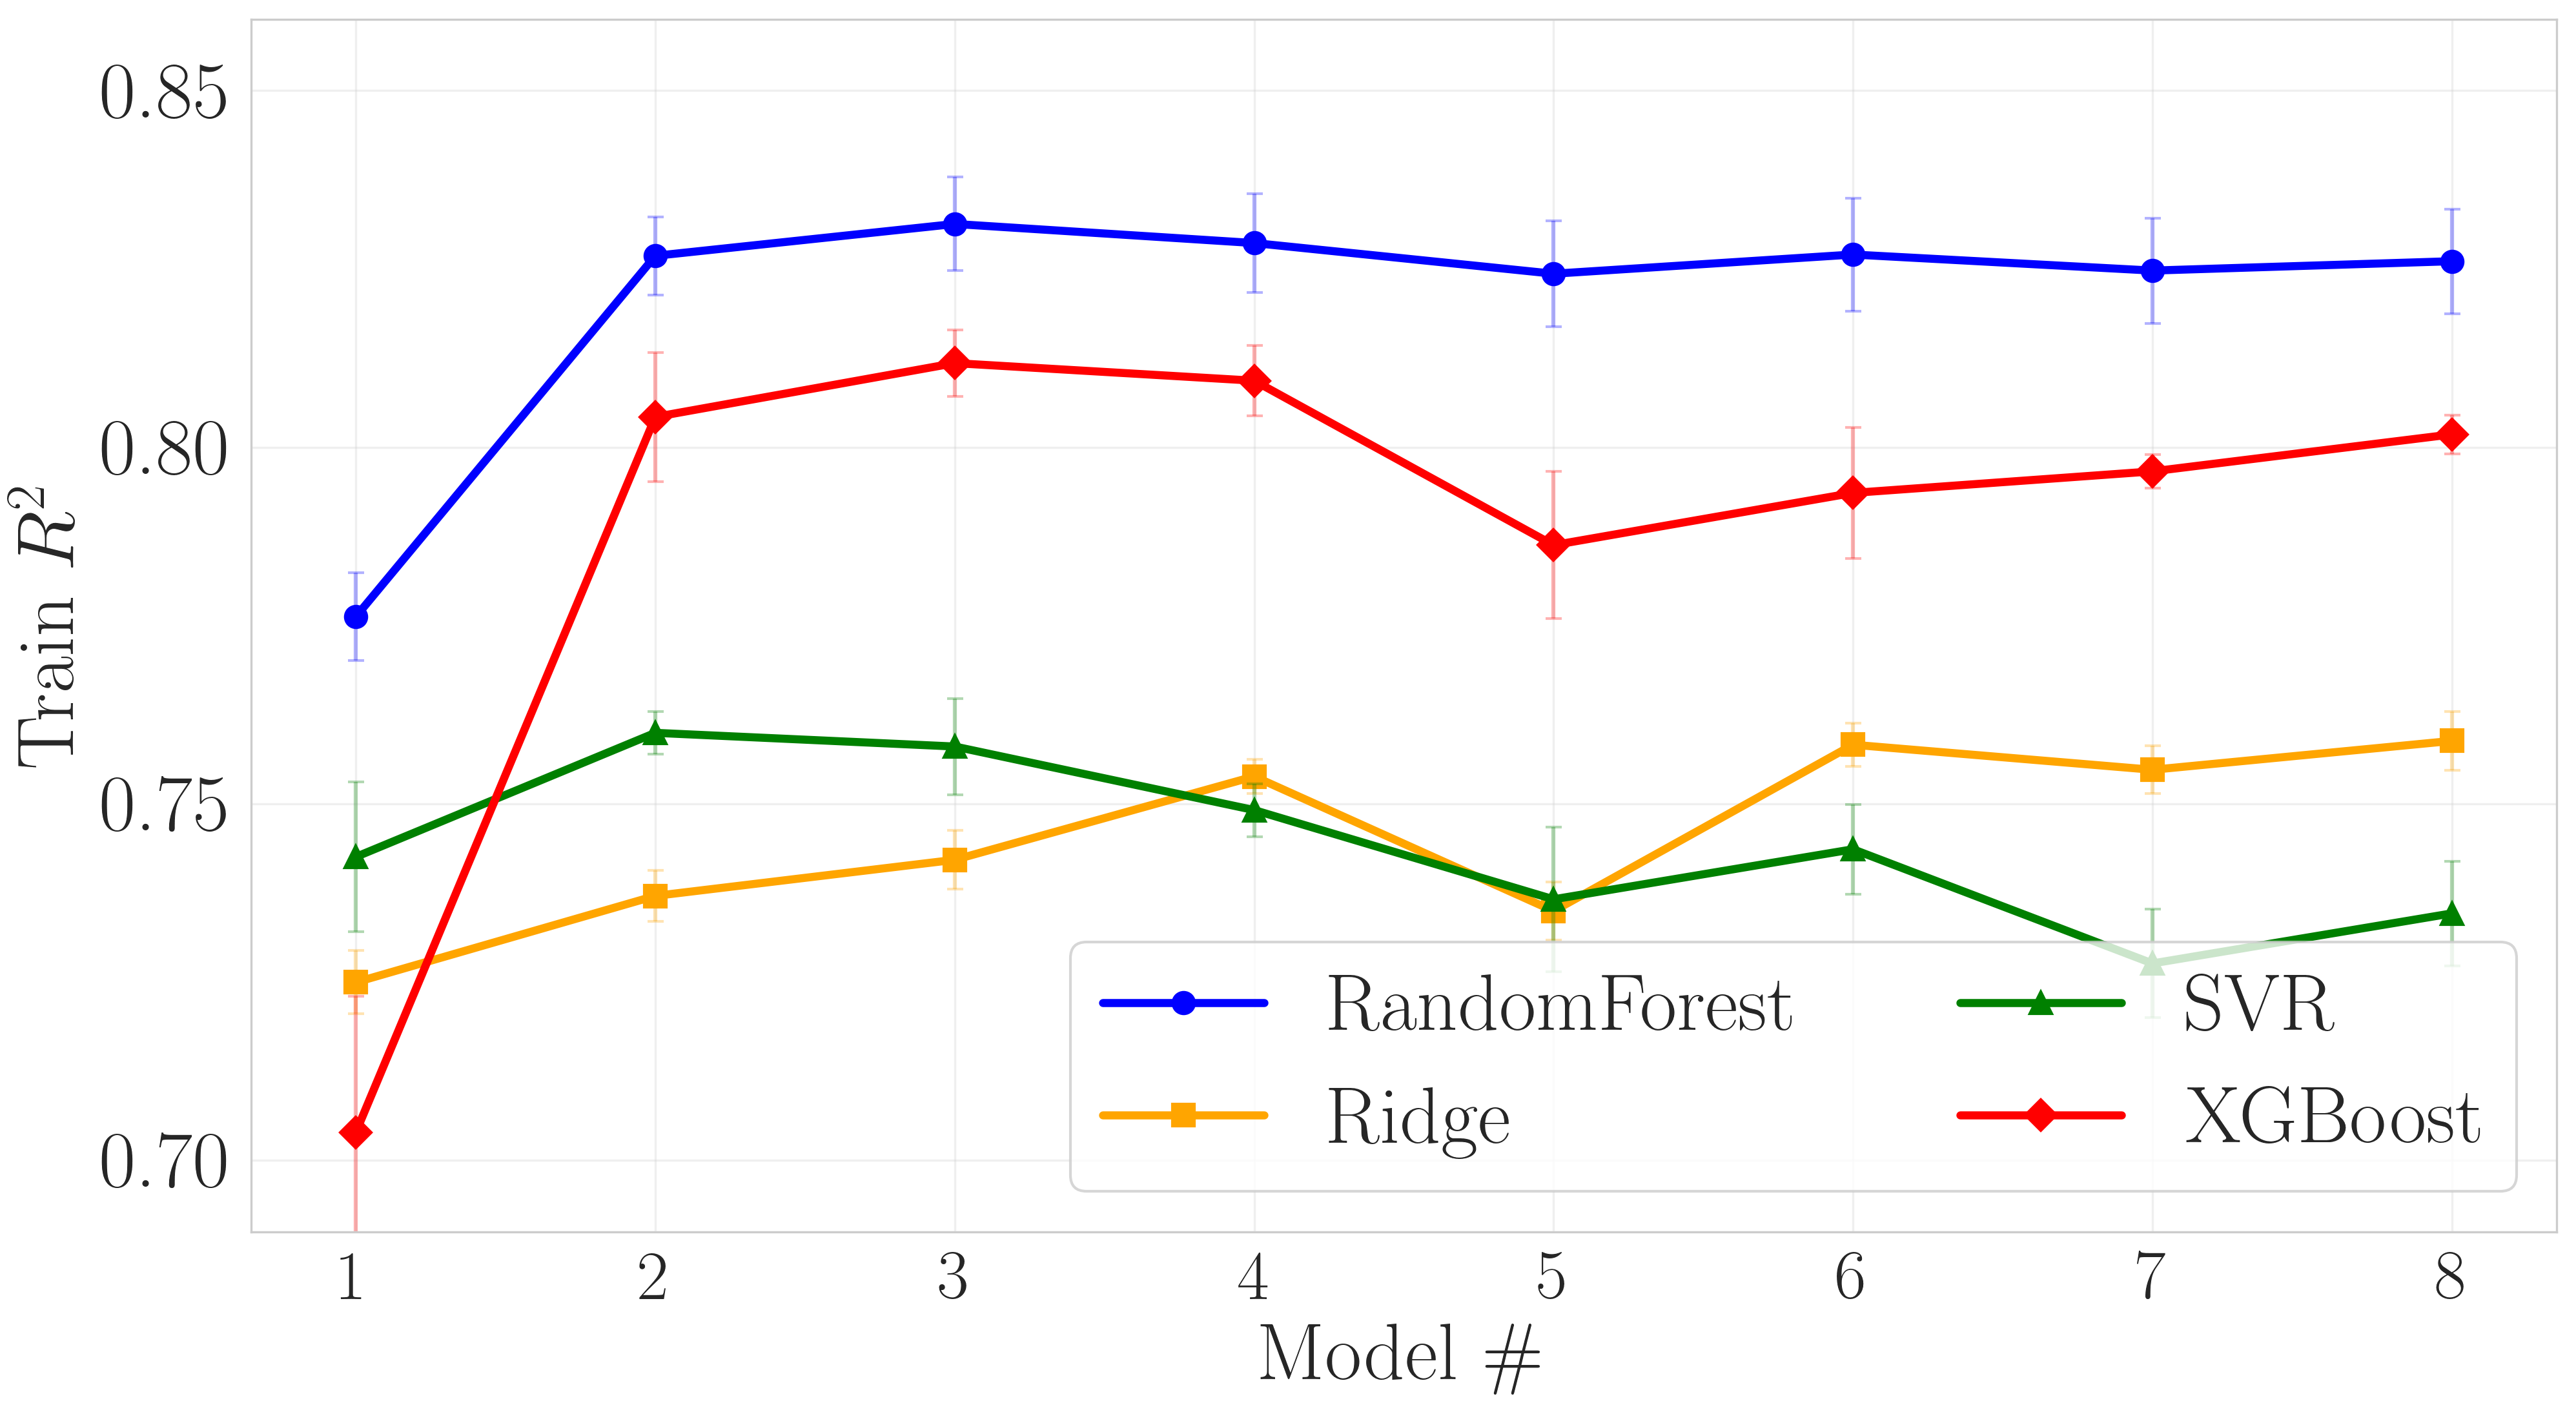

Created separate test and training performance plots
Model comparison completed and results saved to outputs/tests/


In [16]:
if RUN_MODEL_COMPARISON:
    results_df, agg_results = run_model_comparison(MODEL_COMPARISON_SEEDS, True)
    print('Model comparison completed and results saved to outputs/tests/')